In [39]:
import pandas as pd
import numpy as np

In [40]:


df = pd.read_parquet("../data/processed/customer_churn_features")

df.shape
df.head()
df.columns
df.dtypes

customer_id                            object
signup_date                    datetime64[ns]
age                                   float64
gender                                 object
annual_income                         float64
education                              object
marital_status                         object
dependents                            float64
tenure_months                         float64
contract                               object
payment_method                         object
paperless_billing                      object
senior_citizen                          int32
monthly_charges                       float64
total_charges                         float64
num_services                          float64
has_phone_service                       int32
has_internet_service                    int32
has_online_security                     int32
has_online_backup                       int32
has_device_protection                   int32
has_tech_support                  

In [41]:
#lets look at distribution of churned vs non-churned customers
df['churn'].value_counts(normalize=True)

churn
0.0    0.900773
1.0    0.099227
Name: proportion, dtype: float64

## Train, test, split

In [42]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['churn', 'customer_id', 'signup_date', 'churn_label', 'is_month_to_month'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Heavily imbalanced data

4 options, SMOTE, undersampling, oversampling, hybrid sampling

## Lets try doing undersampling and one hot encoding specified variables, along with imputation using median and mode for missing cols

In [43]:
X.dtypes

age                            float64
gender                          object
annual_income                  float64
education                       object
marital_status                  object
dependents                     float64
tenure_months                  float64
contract                        object
payment_method                  object
paperless_billing               object
senior_citizen                   int32
monthly_charges                float64
total_charges                  float64
num_services                   float64
has_phone_service                int32
has_internet_service             int32
has_online_security              int32
has_online_backup                int32
has_device_protection            int32
has_tech_support                 int32
has_streaming_tv                 int32
has_streaming_movies             int32
customer_satisfaction          float64
num_complaints                 float64
num_service_calls                int32
late_payments            

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline


from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler


# Columns you specifically want one-hot encoded
cat_cols = [
    "contract",
    "payment_method",
    "education",
    "gender",
    "marital_status",
    "payment_method",
    "paperless_billing",
    "senior_citizen",
    "has_phone_service",
    "has_internet_service",
    "has_online_security",
    "has_online_backup",
    "has_device_protection",
    "has_tech_support",
    "has_streaming_tv",
    "has_streaming_movies",
    "is_high_monthly_charge",
    "is_new_customer",
    "is_low_satisfaction",
    "is_multi_service_customer"
]

# Every remaining feature is treated as numeric
num_cols = [
    column
    for column in X_train.columns
    if column not in cat_cols
]


# Numeric preprocessing, using median imputation and standard scaling
numeric_pipeline = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)


# Categorical preprocessing, using mode imputation and one-hot encoding
categorical_pipeline = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)


# Apply the correct preprocessing to each column group
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, num_cols),
        ("categorical", categorical_pipeline, cat_cols),
    ]
)

## Make a baseline logistic regression model

In [45]:
from sklearn.linear_model import LogisticRegression


# Preprocess → undersample → logistic regression
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "undersampler",
            RandomUnderSampler(random_state=42),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)


# Train the entire pipeline
model_pipeline.fit(X_train, y_train)


# Predict on the untouched test set
predictions = model_pipeline.predict(X_test)

probabilities = model_pipeline.predict_proba(X_test)[:, 1]

## Print out the summary statistics for logistic regression

In [46]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
)


# --------------------------------------------------
# Confusion matrix values
# --------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    predictions
).ravel()

specificity = tn / (tn + fp)
negative_predictive_value = tn / (tn + fn)


# --------------------------------------------------
# Model evaluation metrics
# --------------------------------------------------

summary_statistics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1 Score",
            "F2 Score",
            "ROC-AUC",
            "PR-AUC",
            "Log Loss",
            "Matthews Correlation",
            "True Negatives",
            "False Positives",
            "False Negatives",
            "True Positives",
        ],
        "Value": [
            accuracy_score(y_test, predictions),
            balanced_accuracy_score(y_test, predictions),
            precision_score(y_test, predictions),
            recall_score(y_test, predictions),
            specificity,
            f1_score(y_test, predictions),
            fbeta_score(y_test, predictions, beta=2),
            roc_auc_score(y_test, probabilities),
            average_precision_score(y_test, probabilities),
            log_loss(y_test, probabilities),
            matthews_corrcoef(y_test, predictions),
            tn,
            fp,
            fn,
            tp,
        ],
    }
)

print(summary_statistics.to_string(index=False))


# --------------------------------------------------
# Full classification report
# --------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        digits=4,
    )
)


# --------------------------------------------------
# Confusion matrix
# --------------------------------------------------

confusion_matrix_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual Non-Churn", "Actual Churn"],
    columns=["Predicted Non-Churn", "Predicted Churn"],
)

print("\nConfusion Matrix:")
print(confusion_matrix_df)


# --------------------------------------------------
# Logistic regression coefficients and odds ratios
# --------------------------------------------------

feature_names = (
    model_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

logistic_model = model_pipeline.named_steps["model"]

coefficient_summary = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": logistic_model.coef_[0],
        "odds_ratio": np.exp(logistic_model.coef_[0]),
    }
)

coefficient_summary["absolute_coefficient"] = (
    coefficient_summary["coefficient"].abs()
)

coefficient_summary = coefficient_summary.sort_values(
    by="absolute_coefficient",
    ascending=False,
)

print("\nIntercept:")
print(logistic_model.intercept_[0])

print("\nMost Influential Features:")
print(
    coefficient_summary[
        ["feature", "coefficient", "odds_ratio"]
    ].head(25).to_string(index=False)
)

              Metric         Value
            Accuracy      0.628015
   Balanced Accuracy      0.631962
           Precision      0.158324
              Recall      0.636886
         Specificity      0.627038
            F1 Score      0.253604
            F2 Score      0.396929
             ROC-AUC      0.684633
              PR-AUC      0.203458
            Log Loss      0.638100
Matthews Correlation      0.161119
      True Negatives 112964.000000
     False Positives  67191.000000
     False Negatives   7206.000000
      True Positives  12639.000000

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9400    0.6270    0.7523    180155
         1.0     0.1583    0.6369    0.2536     19845

    accuracy                         0.6280    200000
   macro avg     0.5492    0.6320    0.5029    200000
weighted avg     0.8625    0.6280    0.7028    200000


Confusion Matrix:
                  Predicted Non-Churn  Predicted Churn
Actual Non-Chur

## Lets check assumptions made for logistic regression

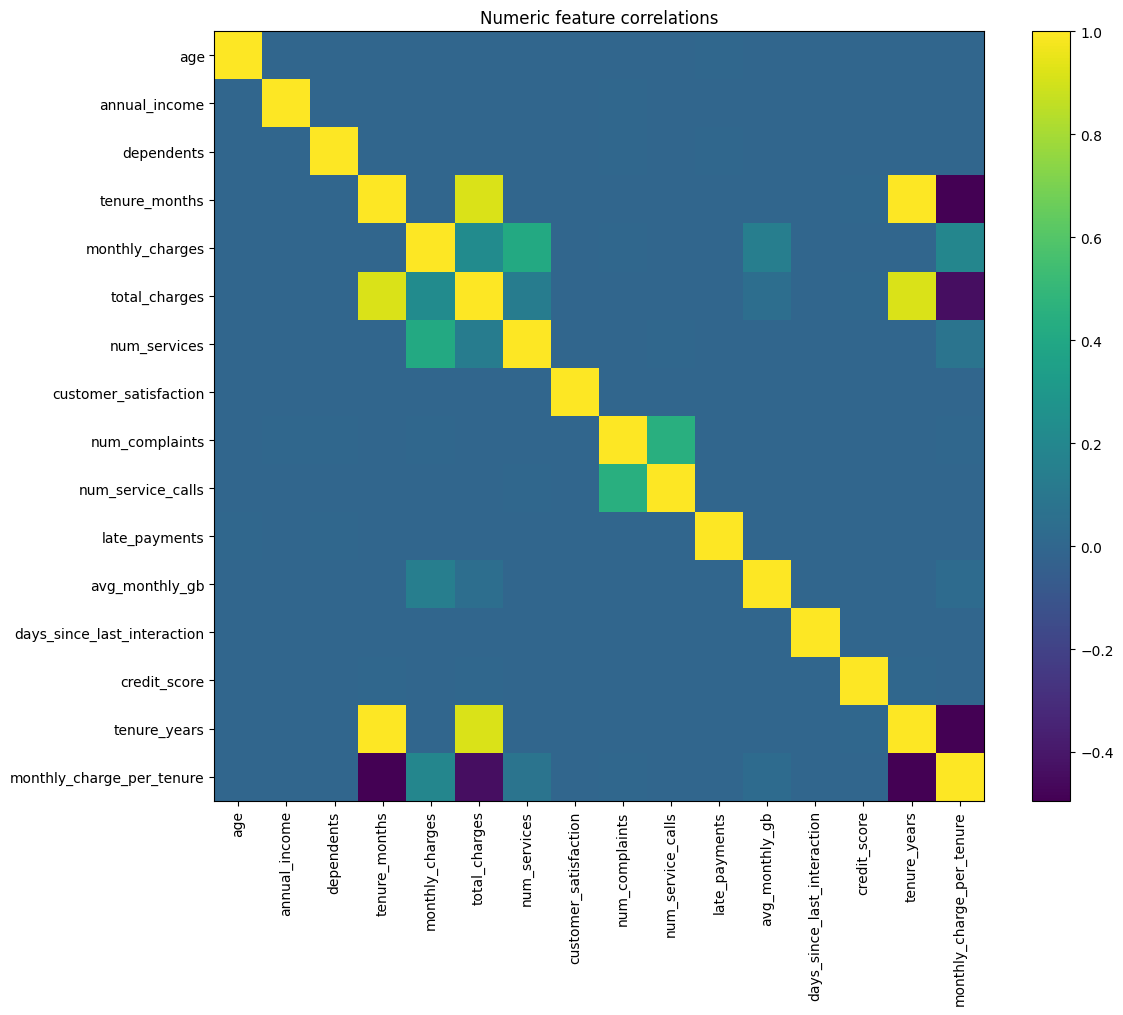

In [47]:
import matplotlib.pyplot as plt

correlation_matrix = X_train[num_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(
    range(len(num_cols)),
    num_cols,
    rotation=90
)
plt.yticks(
    range(len(num_cols)),
    num_cols
)
plt.title("Numeric feature correlations")
plt.tight_layout()
plt.show()

# Lets check VIF

In [48]:
import pandas as pd

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


X_numeric = X_train[num_cols].copy()

X_numeric = SimpleImputer(
    strategy="median"
).fit_transform(X_numeric)

X_numeric = StandardScaler().fit_transform(X_numeric)

vif_results = pd.DataFrame({
    "feature": num_cols,
    "VIF": [
        variance_inflation_factor(X_numeric, index)
        for index in range(X_numeric.shape[1])
    ]
})

vif_results = vif_results.sort_values(
    "VIF",
    ascending=False
)

print(vif_results)

c:\Users\bulle\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                        feature       VIF
3                 tenure_months       inf
14                 tenure_years       inf
5                 total_charges  8.927686
4               monthly_charges  1.682661
15    monthly_charge_per_tenure  1.407236
8                num_complaints  1.243296
9             num_service_calls  1.243276
6                  num_services  1.233080
11               avg_monthly_gb  1.026919
2                    dependents  1.000024
13                 credit_score  1.000021
7         customer_satisfaction  1.000016
12  days_since_last_interaction  1.000014
10                late_payments  1.000013
1                 annual_income  1.000012
0                           age  1.000010


### Multicollinearity adjustment

The VIF analysis showed infinite VIF values for `tenure_months` and
`tenure_years`. Since `tenure_years` is directly calculated from
`tenure_months`, the two variables contain the same information.

I retained `tenure_months` because it provides greater precision and removed
`tenure_years` before retraining the model.

In [49]:
X = X.drop(columns=["tenure_years"])

num_cols.remove("tenure_years")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

model_pipeline.fit(X_train, y_train)

predictions = model_pipeline.predict(X_test)
probabilities = model_pipeline.predict_proba(X_test)[:, 1]

## Recalculate VIF with dropped cols

In [50]:
X_numeric = X_train[num_cols].copy()

X_numeric = SimpleImputer(
    strategy="median"
).fit_transform(X_numeric)

X_numeric = StandardScaler().fit_transform(X_numeric)

vif_results = pd.DataFrame({
    "feature": num_cols,
    "VIF": [
        variance_inflation_factor(X_numeric, index)
        for index in range(X_numeric.shape[1])
    ]
})

vif_results = vif_results.sort_values(
    "VIF",
    ascending=False
)

print(vif_results)

                        feature       VIF
5                 total_charges  8.927706
3                 tenure_months  8.429564
4               monthly_charges  1.682661
14    monthly_charge_per_tenure  1.407222
8                num_complaints  1.243297
9             num_service_calls  1.243276
6                  num_services  1.233080
11               avg_monthly_gb  1.026921
2                    dependents  1.000025
13                 credit_score  1.000021
7         customer_satisfaction  1.000016
1                 annual_income  1.000015
12  days_since_last_interaction  1.000015
10                late_payments  1.000013
0                           age  1.000012


## Lets drop total_charges due to coefficient being low and wasn't a key insight 

In [51]:
X = X.drop(columns=["total_charges"])
num_cols.remove("total_charges")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Recalculate VIF again

In [52]:

X_numeric = X_train[num_cols].copy()

X_numeric = SimpleImputer(
    strategy="median"
).fit_transform(X_numeric)

X_numeric = StandardScaler().fit_transform(X_numeric)

vif_results = pd.DataFrame({
    "feature": num_cols,
    "VIF": [
        variance_inflation_factor(X_numeric, index)
        for index in range(X_numeric.shape[1])
    ]
})

vif_results = vif_results.sort_values(
    "VIF",
    ascending=False
)

print(vif_results)

                        feature       VIF
13    monthly_charge_per_tenure  1.389784
3                 tenure_months  1.339776
4               monthly_charges  1.284641
7                num_complaints  1.243295
8             num_service_calls  1.243276
5                  num_services  1.210602
10               avg_monthly_gb  1.024216
2                    dependents  1.000023
12                 credit_score  1.000018
1                 annual_income  1.000015
11  days_since_last_interaction  1.000015
9                 late_payments  1.000013
0                           age  1.000012
6         customer_satisfaction  1.000008


# It assumes each continuous variable has an approximately linear relationship with the log-odds of churn, lets check that assumption

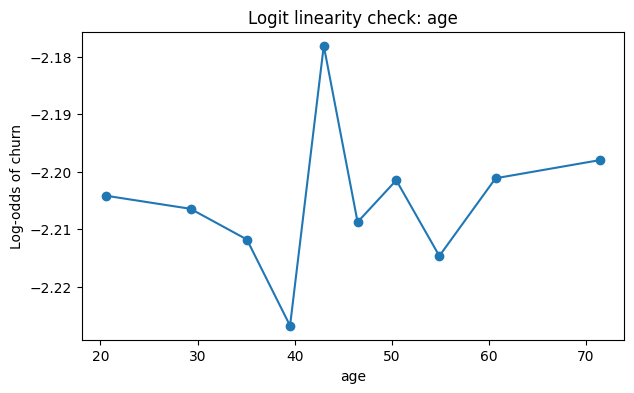

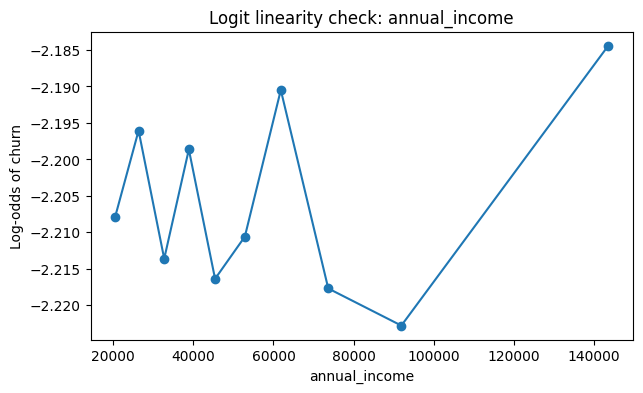

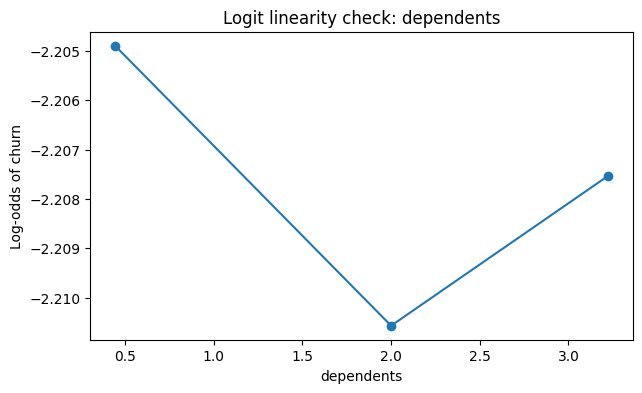

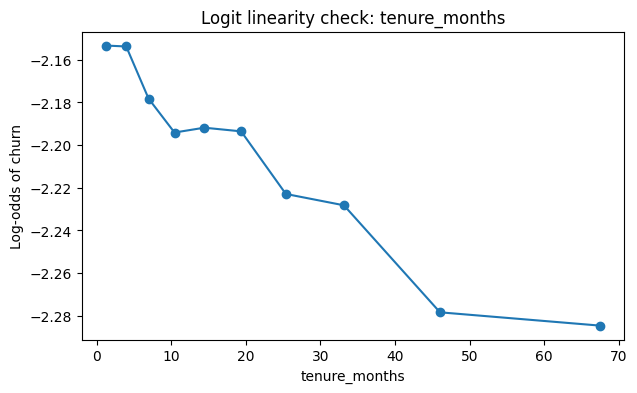

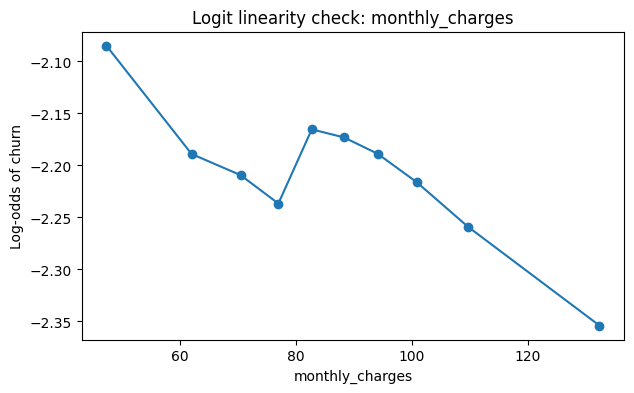

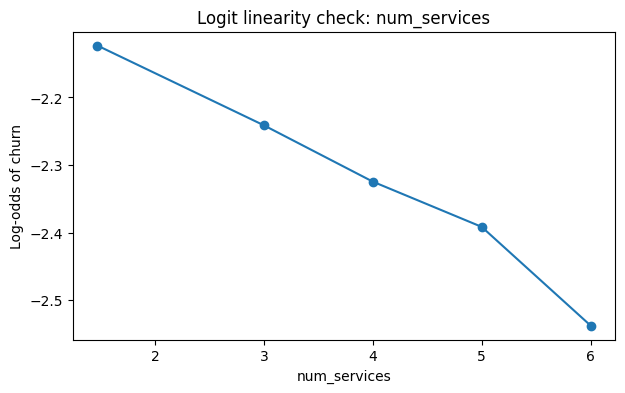

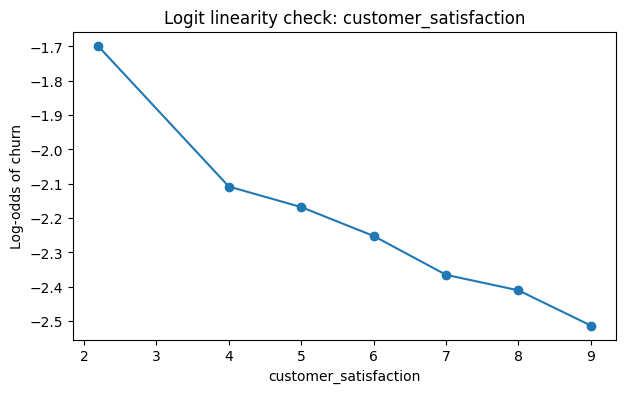

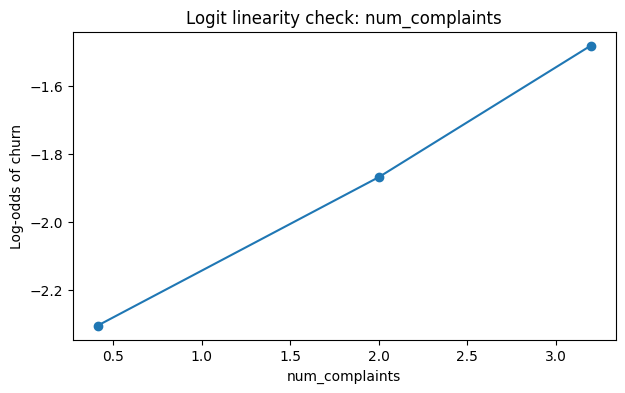

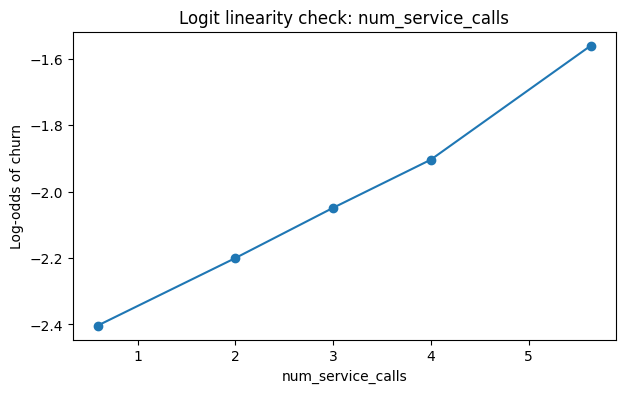

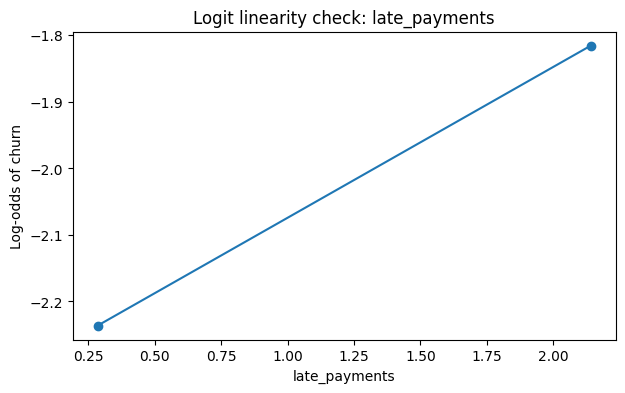

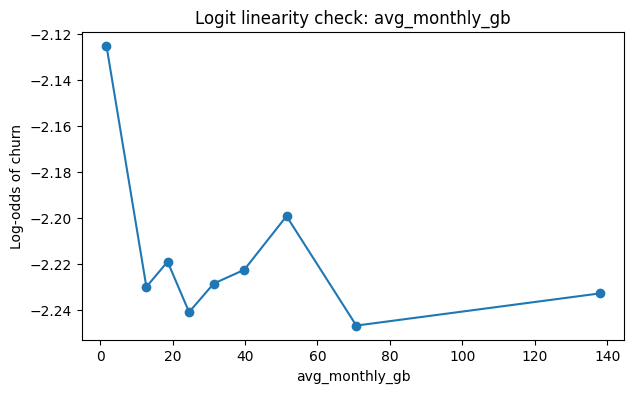

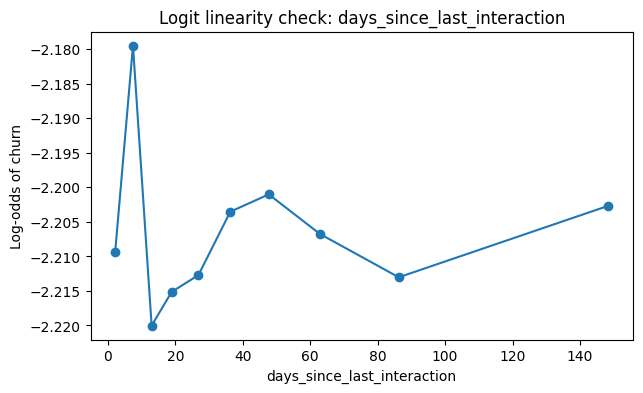

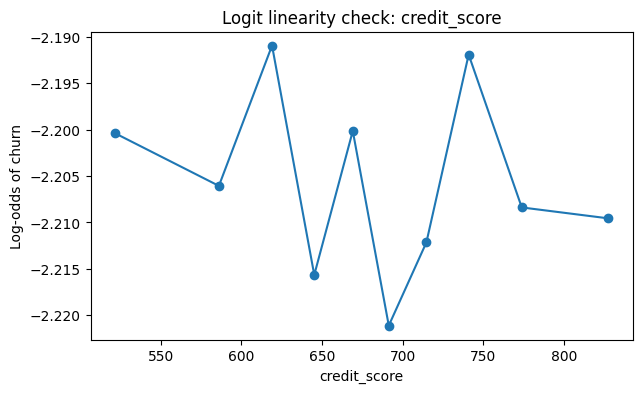

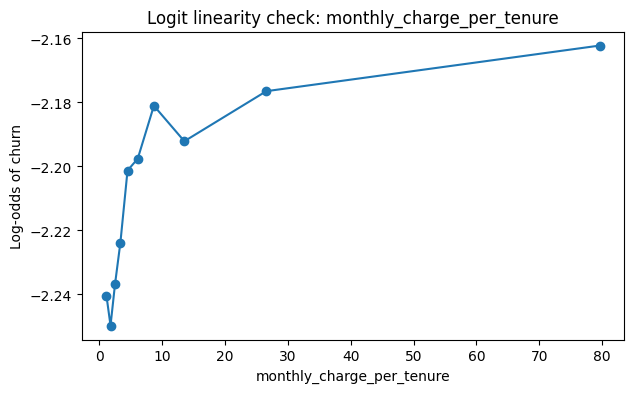

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for column in num_cols:
    check_df = pd.DataFrame({
        "feature": X_train[column],
        "target": y_train,
    }).dropna()

    # Divide the feature into 10 roughly equal-sized groups
    check_df["bin"] = pd.qcut(
        check_df["feature"],
        q=10,
        duplicates="drop",
    )

    logit_summary = (
        check_df
        .groupby("bin", observed=True)
        .agg(
            mean_feature=("feature", "mean"),
            churn_rate=("target", "mean"),
        )
        .reset_index()
    )

    # Prevent division by zero
    logit_summary["churn_rate"] = (
        logit_summary["churn_rate"]
        .clip(0.0001, 0.9999)
    )

    logit_summary["log_odds"] = np.log(
        logit_summary["churn_rate"]
        / (1 - logit_summary["churn_rate"])
    )

    plt.figure(figsize=(7, 4))

    plt.plot(
        logit_summary["mean_feature"],
        logit_summary["log_odds"],
        marker="o",
    )

    plt.xlabel(column)
    plt.ylabel("Log-odds of churn")
    plt.title(f"Logit linearity check: {column}")
    plt.show()

## verifying

In [54]:
nonlinear_cols = [
    "monthly_charge_per_tenure",
    "avg_monthly_gb",
]

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    SplineTransformer,
)
from sklearn.impute import SimpleImputer


nonlinear_cols = [
    "monthly_charge_per_tenure",
    "avg_monthly_gb",
]

linear_num_cols = [
    column
    for column in num_cols
    if column not in nonlinear_cols
]


linear_numeric_pipeline = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)


nonlinear_numeric_pipeline = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "spline",
            SplineTransformer(
                n_knots=5,
                degree=3,
                include_bias=False,
            ),
        ),
        ("scaler", StandardScaler()),
    ]
)


categorical_pipeline = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "linear_numeric",
            linear_numeric_pipeline,
            linear_num_cols,
        ),
        (
            "nonlinear_numeric",
            nonlinear_numeric_pipeline,
            nonlinear_cols,
        ),
        (
            "categorical",
            categorical_pipeline,
            cat_cols,
        ),
    ]
)

# Retrain model with splines

In [55]:
from sklearn.linear_model import LogisticRegression


# Preprocess → undersample → logistic regression
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "undersampler",
            RandomUnderSampler(random_state=42),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)


# Train the entire pipeline
model_pipeline.fit(X_train, y_train)


# Predict on the untouched test set
predictions = model_pipeline.predict(X_test)

probabilities = model_pipeline.predict_proba(X_test)[:, 1]

## Print evaluation metrics

In [56]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
)


# --------------------------------------------------
# Confusion matrix values
# --------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    predictions
).ravel()

specificity = tn / (tn + fp)
negative_predictive_value = tn / (tn + fn)


# --------------------------------------------------
# Model evaluation metrics
# --------------------------------------------------

summary_statistics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1 Score",
            "F2 Score",
            "ROC-AUC",
            "PR-AUC",
            "Log Loss",
            "Matthews Correlation",
            "True Negatives",
            "False Positives",
            "False Negatives",
            "True Positives",
        ],
        "Value": [
            accuracy_score(y_test, predictions),
            balanced_accuracy_score(y_test, predictions),
            precision_score(y_test, predictions),
            recall_score(y_test, predictions),
            specificity,
            f1_score(y_test, predictions),
            fbeta_score(y_test, predictions, beta=2),
            roc_auc_score(y_test, probabilities),
            average_precision_score(y_test, probabilities),
            log_loss(y_test, probabilities),
            matthews_corrcoef(y_test, predictions),
            tn,
            fp,
            fn,
            tp,
        ],
    }
)

print(summary_statistics.to_string(index=False))


# --------------------------------------------------
# Full classification report
# --------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        digits=4,
    )
)


# --------------------------------------------------
# Confusion matrix
# --------------------------------------------------

confusion_matrix_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual Non-Churn", "Actual Churn"],
    columns=["Predicted Non-Churn", "Predicted Churn"],
)

print("\nConfusion Matrix:")
print(confusion_matrix_df)


# --------------------------------------------------
# Logistic regression coefficients and odds ratios
# --------------------------------------------------

feature_names = (
    model_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

logistic_model = model_pipeline.named_steps["model"]

coefficient_summary = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": logistic_model.coef_[0],
        "odds_ratio": np.exp(logistic_model.coef_[0]),
    }
)

coefficient_summary["absolute_coefficient"] = (
    coefficient_summary["coefficient"].abs()
)

coefficient_summary = coefficient_summary.sort_values(
    by="absolute_coefficient",
    ascending=False,
)

print("\nIntercept:")
print(logistic_model.intercept_[0])

print("\nMost Influential Features:")
print(
    coefficient_summary[
        ["feature", "coefficient", "odds_ratio"]
    ].head(25).to_string(index=False)
)

              Metric         Value
            Accuracy      0.628190
   Balanced Accuracy      0.631790
           Precision      0.158291
              Recall      0.636281
         Specificity      0.627299
            F1 Score      0.253513
            F2 Score      0.396699
             ROC-AUC      0.684544
              PR-AUC      0.203316
            Log Loss      0.638192
Matthews Correlation      0.160929
      True Negatives 113011.000000
     False Positives  67144.000000
     False Negatives   7218.000000
      True Positives  12627.000000

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9400    0.6273    0.7524    180155
         1.0     0.1583    0.6363    0.2535     19845

    accuracy                         0.6282    200000
   macro avg     0.5491    0.6318    0.5030    200000
weighted avg     0.8624    0.6282    0.7029    200000


Confusion Matrix:
                  Predicted Non-Churn  Predicted Churn
Actual Non-Chur

## Getting the coefficients for logistic regression

In [57]:
# --------------------------------------------------
# Logistic regression coefficients and odds ratios
# --------------------------------------------------

preprocessor = model_pipeline.named_steps["preprocessor"]
logistic_model = model_pipeline.named_steps["model"]

# Get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get coefficients from the fitted logistic regression
coefficients = logistic_model.coef_[0]

# Confirm that every processed feature has a coefficient
if len(feature_names) != len(coefficients):
    raise ValueError(
        f"Feature count ({len(feature_names)}) does not match "
        f"coefficient count ({len(coefficients)})."
    )

coefficient_summary = pd.DataFrame(
    {
        "Feature": feature_names,
        "Coefficient": coefficients,
    }
)

# Remove prefixes such as numeric__ and categorical__
coefficient_summary["Feature"] = (
    coefficient_summary["Feature"]
    .str.replace(r"^[^_]+__", "", regex=True)
)

# Convert coefficients into business-friendly interpretations
coefficient_summary["Odds Ratio"] = np.exp(
    coefficient_summary["Coefficient"]
)

coefficient_summary["Odds Change (%)"] = (
    coefficient_summary["Odds Ratio"] - 1
) * 100

coefficient_summary["Direction"] = np.where(
    coefficient_summary["Coefficient"] > 0,
    "Increases churn risk",
    "Decreases churn risk",
)

coefficient_summary["Absolute Coefficient"] = (
    coefficient_summary["Coefficient"].abs()
)


# --------------------------------------------------
# Intercept
# --------------------------------------------------

print("\nLogistic Regression Intercept:")
print(round(logistic_model.intercept_[0], 4))


# --------------------------------------------------
# Features that increase churn risk
# --------------------------------------------------

churn_increasing_features = (
    coefficient_summary[
        coefficient_summary["Coefficient"] > 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=False,
    )
    .head(15)
)

print("\nTop Features Increasing Churn Risk:")
print(
    churn_increasing_features[
        [
            "Feature",
            "Coefficient",
            "Odds Ratio",
            "Odds Change (%)",
        ]
    ].to_string(
        index=False,
        formatters={
            "Coefficient": "{:.4f}".format,
            "Odds Ratio": "{:.4f}".format,
            "Odds Change (%)": "{:.2f}%".format,
        },
    )
)


# --------------------------------------------------
# Features that decrease churn risk
# --------------------------------------------------

churn_decreasing_features = (
    coefficient_summary[
        coefficient_summary["Coefficient"] < 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=True,
    )
    .head(15)
)

print("\nTop Features Decreasing Churn Risk:")
print(
    churn_decreasing_features[
        [
            "Feature",
            "Coefficient",
            "Odds Ratio",
            "Odds Change (%)",
        ]
    ].to_string(
        index=False,
        formatters={
            "Coefficient": "{:.4f}".format,
            "Odds Ratio": "{:.4f}".format,
            "Odds Change (%)": "{:.2f}%".format,
        },
    )
)


# --------------------------------------------------
# Most influential features overall
# --------------------------------------------------

most_influential_features = (
    coefficient_summary
    .sort_values(
        by="Absolute Coefficient",
        ascending=False,
    )
    .head(25)
)

print("\nMost Influential Features Overall:")
print(
    most_influential_features[
        [
            "Feature",
            "Coefficient",
            "Odds Ratio",
            "Odds Change (%)",
            "Direction",
        ]
    ].to_string(
        index=False,
        formatters={
            "Coefficient": "{:.4f}".format,
            "Odds Ratio": "{:.4f}".format,
            "Odds Change (%)": "{:.2f}%".format,
        },
    )
)


Logistic Regression Intercept:
0.0221

Top Features Increasing Churn Risk:
                                          Feature Coefficient Odds Ratio Odds Change (%)
                          contract_month_to_month      0.9890     2.6887         168.87%
                   linear_numeric__num_complaints      0.1715     1.1871          18.71%
                               has_tech_support_0      0.1702     1.1856          18.56%
                linear_numeric__num_service_calls      0.1666     1.1813          18.13%
                    linear_numeric__late_payments      0.1539     1.1664          16.64%
                            has_online_security_0      0.1359     1.1456          14.56%
                            is_low_satisfaction_1      0.0797     1.0829           8.29%
                         is_high_monthly_charge_1      0.0453     1.0463           4.63%
                          marital_status_divorced      0.0372     1.0379           3.79%
                           marital

## Better coeficient comparison

In [58]:
# --------------------------------------------------
# Business-friendly category comparisons
# --------------------------------------------------

coefficient_lookup = (
    coefficient_summary
    .set_index("Feature")["Coefficient"]
)

category_comparisons = [
    (
        "Month-to-month vs Two-year contract",
        "contract_month_to_month",
        "contract_two_year",
    ),
    (
        "Month-to-month vs One-year contract",
        "contract_month_to_month",
        "contract_one_year",
    ),
    (
        "No tech support vs Tech support",
        "has_tech_support_0",
        "has_tech_support_1",
    ),
    (
        "No online security vs Online security",
        "has_online_security_0",
        "has_online_security_1",
    ),
    (
        "Low satisfaction vs Not low satisfaction",
        "is_low_satisfaction_1",
        "is_low_satisfaction_0",
    ),
    (
        "High monthly charge vs Not high monthly charge",
        "is_high_monthly_charge_1",
        "is_high_monthly_charge_0",
    ),
]

comparison_rows = []

for comparison, first_feature, second_feature in category_comparisons:

    coefficient_difference = (
        coefficient_lookup[first_feature]
        - coefficient_lookup[second_feature]
    )

    odds_ratio = np.exp(coefficient_difference)

    comparison_rows.append(
        {
            "Comparison": comparison,
            "Coefficient Difference": coefficient_difference,
            "Odds Ratio": odds_ratio,
            "Odds Change (%)": (odds_ratio - 1) * 100,
        }
    )

business_category_summary = pd.DataFrame(comparison_rows)

print("\nBusiness-Friendly Category Comparisons:")

print(
    business_category_summary.to_string(
        index=False,
        formatters={
            "Coefficient Difference": "{:.4f}".format,
            "Odds Ratio": "{:.2f}x".format,
            "Odds Change (%)": "{:+.1f}%".format,
        },
    )
)


Business-Friendly Category Comparisons:
                                    Comparison Coefficient Difference Odds Ratio Odds Change (%)
           Month-to-month vs Two-year contract                 1.9289      6.88x         +588.2%
           Month-to-month vs One-year contract                 1.0162      2.76x         +176.3%
               No tech support vs Tech support                 0.3184      1.37x          +37.5%
         No online security vs Online security                 0.2497      1.28x          +28.4%
      Low satisfaction vs Not low satisfaction                 0.1373      1.15x          +14.7%
High monthly charge vs Not high monthly charge                 0.0685      1.07x           +7.1%


Month-to-month contracts were the strongest churn indicator. Customers with more complaints, service calls, and late payments also showed higher predicted churn risk, while higher satisfaction, longer tenure, additional services, technical support, and online security were associated with lower risk.

## Probability calibration

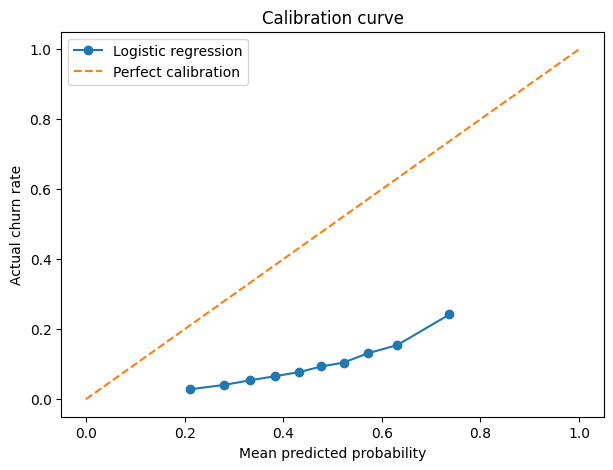

Brier score: 0.22362417163371975


In [19]:
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fraction_positive, mean_predicted = calibration_curve(
    y_test,
    probabilities,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(7, 5))

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    label="Logistic regression",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual churn rate")
plt.title("Calibration curve")
plt.legend()
plt.show()

print(
    "Brier score:",
    brier_score_loss(
        y_test,
        probabilities,
    ),
)

## above shows we are over estimating who should churn

# Now lets try without undersampling, but with balancing

In [20]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
)

from imblearn.pipeline import Pipeline


# --------------------------------------------------
# Build class-weighted logistic regression
# --------------------------------------------------

model_pipeline_weighted = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)


# --------------------------------------------------
# Train model
# --------------------------------------------------

model_pipeline_weighted.fit(
    X_train,
    y_train,
)


# --------------------------------------------------
# Predictions and probabilities
# --------------------------------------------------

weighted_predictions = (
    model_pipeline_weighted.predict(X_test)
)

weighted_probabilities = (
    model_pipeline_weighted.predict_proba(X_test)[:, 1]
)


# --------------------------------------------------
# Confusion matrix values
# --------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    weighted_predictions,
).ravel()

specificity = tn / (tn + fp)


# --------------------------------------------------
# Evaluation metrics
# --------------------------------------------------

summary_statistics_weighted = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1 Score",
            "F2 Score",
            "ROC-AUC",
            "PR-AUC",
            "Log Loss",
            "Matthews Correlation",
            "True Negatives",
            "False Positives",
            "False Negatives",
            "True Positives",
        ],
        "Value": [
            accuracy_score(
                y_test,
                weighted_predictions,
            ),
            balanced_accuracy_score(
                y_test,
                weighted_predictions,
            ),
            precision_score(
                y_test,
                weighted_predictions,
            ),
            recall_score(
                y_test,
                weighted_predictions,
            ),
            specificity,
            f1_score(
                y_test,
                weighted_predictions,
            ),
            fbeta_score(
                y_test,
                weighted_predictions,
                beta=2,
            ),
            roc_auc_score(
                y_test,
                weighted_probabilities,
            ),
            average_precision_score(
                y_test,
                weighted_probabilities,
            ),
            log_loss(
                y_test,
                weighted_probabilities,
            ),
            matthews_corrcoef(
                y_test,
                weighted_predictions,
            ),
            tn,
            fp,
            fn,
            tp,
        ],
    }
)

print(
    summary_statistics_weighted.to_string(
        index=False
    )
)


# --------------------------------------------------
# Classification report
# --------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        weighted_predictions,
        digits=4,
    )
)


# --------------------------------------------------
# Confusion matrix
# --------------------------------------------------

confusion_matrix_weighted = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=[
        "Actual Non-Churn",
        "Actual Churn",
    ],
    columns=[
        "Predicted Non-Churn",
        "Predicted Churn",
    ],
)

print("\nConfusion Matrix:")
print(confusion_matrix_weighted)


# --------------------------------------------------
# Coefficients and odds ratios
# --------------------------------------------------

feature_names = (
    model_pipeline_weighted
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

weighted_logistic_model = (
    model_pipeline_weighted
    .named_steps["model"]
)

coefficient_summary_weighted = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": (
            weighted_logistic_model.coef_[0]
        ),
        "odds_ratio": np.exp(
            weighted_logistic_model.coef_[0]
        ),
    }
)

coefficient_summary_weighted[
    "absolute_coefficient"
] = (
    coefficient_summary_weighted[
        "coefficient"
    ].abs()
)

coefficient_summary_weighted = (
    coefficient_summary_weighted.sort_values(
        by="absolute_coefficient",
        ascending=False,
    )
)

print("\nIntercept:")
print(weighted_logistic_model.intercept_[0])

print("\nMost Influential Features:")

print(
    coefficient_summary_weighted[
        [
            "feature",
            "coefficient",
            "odds_ratio",
        ]
    ]
    .head(25)
    .to_string(index=False)
)

              Metric         Value
            Accuracy      0.629255
   Balanced Accuracy      0.632000
           Precision      0.158568
              Recall      0.635425
         Specificity      0.628575
            F1 Score      0.253801
            F2 Score      0.396780
             ROC-AUC      0.684752
              PR-AUC      0.203604
            Log Loss      0.637266
Matthews Correlation      0.161270
      True Negatives 113241.000000
     False Positives  66914.000000
     False Negatives   7235.000000
      True Positives  12610.000000

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9399    0.6286    0.7534    180155
         1.0     0.1586    0.6354    0.2538     19845

    accuracy                         0.6293    200000
   macro avg     0.5493    0.6320    0.5036    200000
weighted avg     0.8624    0.6293    0.7038    200000


Confusion Matrix:
                  Predicted Non-Churn  Predicted Churn
Actual Non-Chur

# Lets do cross validation stratified with our weighted balance class above

In [21]:
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
)


# --------------------------------------------------
# 1. Create stratified folds
# --------------------------------------------------

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


# --------------------------------------------------
# 2. Metrics to calculate in every fold
# --------------------------------------------------

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0,
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0,
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0,
    ),

    "f2": make_scorer(
        fbeta_score,
        beta=2,
        zero_division=0,
    ),

    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "neg_log_loss": "neg_log_loss",

    "mcc": make_scorer(
        matthews_corrcoef,
    ),
}


# --------------------------------------------------
# 3. Run stratified cross-validation
# --------------------------------------------------

cv_results = cross_validate(
    estimator=model_pipeline_weighted,
    X=X_train,
    y=y_train,
    cv=stratified_cv,
    scoring=scoring,
    return_train_score=True,

    # Use 1 for lower memory usage with your large dataset
    n_jobs=1,

    verbose=2,
)


# --------------------------------------------------
# 4. Summarize mean and standard deviation
# --------------------------------------------------

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
    "neg_log_loss",
    "mcc",
]

summary_rows = []

for metric in metric_names:
    train_values = cv_results[f"train_{metric}"]
    validation_values = cv_results[f"test_{metric}"]

    display_name = metric

    # Scikit-learn reports log loss as negative
    if metric == "neg_log_loss":
        train_values = -train_values
        validation_values = -validation_values
        display_name = "log_loss"

    summary_rows.append(
        {
            "Metric": display_name,
            "Train Mean": train_values.mean(),
            "Validation Mean": validation_values.mean(),
            "Validation Std": validation_values.std(),
        }
    )


cv_summary = pd.DataFrame(summary_rows)

print("\nStratified Cross-Validation Results:")
print(
    cv_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# --------------------------------------------------
# 5. Display timing
# --------------------------------------------------

print(
    "\nAverage fit time:",
    round(cv_results["fit_time"].mean(), 2),
    "seconds",
)

print(
    "Total fit time:",
    round(cv_results["fit_time"].sum(), 2),
    "seconds",
)

[CV] END .................................................... total time=  12.6s
[CV] END .................................................... total time=  12.1s
[CV] END .................................................... total time=  12.6s
[CV] END .................................................... total time=  12.5s
[CV] END .................................................... total time=  12.5s

Stratified Cross-Validation Results:
           Metric  Train Mean  Validation Mean  Validation Std
         accuracy    0.629449         0.629309        0.000886
balanced_accuracy    0.634355         0.634175        0.001943
        precision    0.159509         0.159414        0.000894
           recall    0.640476         0.640246        0.003441
               f1    0.255409         0.255268        0.001413
               f2    0.399533         0.399342        0.002177
          roc_auc    0.685967         0.685635        0.002255
           pr_auc    0.202545         0.202426       

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  2.1min finished


### Stratified cross-validation conclusion

Five-fold stratified cross-validation showed highly consistent performance
across folds. Validation PR-AUC averaged 0.2024 with a standard deviation of
0.0005, while validation ROC-AUC averaged 0.6856 with a standard deviation of
0.0023.

Training and validation metrics were nearly identical, indicating that the
class-weighted logistic regression did not meaningfully overfit. The model
consistently detected approximately 64% of churners, although precision
remained low at approximately 16%.

The logistic regression was retained as a stable and interpretable baseline
for comparison with more flexible tree-based models.

## Lets try random forest next against out baseline

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier


# Numeric columns: impute only
rf_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
    ]
)


# Categorical columns: impute and one-hot encode
rf_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary",
            ),
        ),
    ]
)


rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            rf_numeric_pipeline,
            num_cols,
        ),
        (
            "categorical",
            rf_categorical_pipeline,
            cat_cols,
        ),
    ]
)


rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor,
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=20,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

# cross validation

In [23]:
from sklearn.model_selection import cross_validate


rf_cv_results = cross_validate(
    estimator=rf_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_cv,
    scoring=scoring,
    return_train_score=True,

    # The forest already uses all processor cores
    n_jobs=1,

    verbose=2,
)

[CV] END .................................................... total time= 1.7min
[CV] END .................................................... total time= 1.7min
[CV] END .................................................... total time= 1.7min
[CV] END .................................................... total time= 1.7min
[CV] END .................................................... total time= 1.8min


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 10.5min finished


## Results

In [24]:
import pandas as pd


metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
    "neg_log_loss",
    "mcc",
]

summary_rows = []

for metric in metric_names:
    train_values = rf_cv_results[f"train_{metric}"]
    validation_values = rf_cv_results[f"test_{metric}"]

    display_name = metric

    if metric == "neg_log_loss":
        train_values = -train_values
        validation_values = -validation_values
        display_name = "log_loss"

    summary_rows.append(
        {
            "Metric": display_name,
            "Train Mean": train_values.mean(),
            "Validation Mean": validation_values.mean(),
            "Validation Std": validation_values.std(),
        }
    )


rf_cv_summary = pd.DataFrame(summary_rows)

print("\nRandom Forest Cross-Validation Results:")

print(
    rf_cv_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nAverage fit time:",
    round(rf_cv_results["fit_time"].mean(), 2),
    "seconds",
)





Random Forest Cross-Validation Results:
           Metric  Train Mean  Validation Mean  Validation Std
         accuracy    0.955470         0.861554        0.001216
balanced_accuracy    0.899418         0.554630        0.000793
        precision    0.748859         0.232517        0.003227
           recall    0.829489         0.171714        0.002165
               f1    0.787105         0.197522        0.001651
               f2    0.811996         0.181180        0.001887
          roc_auc    0.978884         0.666899        0.001528
           pr_auc    0.881777         0.183228        0.002465
         log_loss    0.362604         0.443826        0.000598
              mcc    0.763561         0.125352        0.002092

Average fit time: 99.42 seconds


## Above shows complete overfitting, lets make a less complex random forest

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


rf_pipeline_reduced = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,

                # Reduce tree complexity
                max_depth=10,
                min_samples_split=100,
                min_samples_leaf=50,

                # Reduce correlation between trees
                max_features="sqrt",
                max_samples=0.70,

                # Handle imbalance
                class_weight="balanced_subsample",

                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

rf_cv_results_reduced = cross_validate(
    estimator=rf_pipeline_reduced,
    X=X_train,
    y=y_train,
    cv=stratified_cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=1,
    verbose=2,
)

import pandas as pd


metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
    "neg_log_loss",
    "mcc",
]

summary_rows = []

for metric in metric_names:
    train_values = rf_cv_results_reduced[
        f"train_{metric}"
    ]

    validation_values = rf_cv_results_reduced[
        f"test_{metric}"
    ]

    display_name = metric

    if metric == "neg_log_loss":
        train_values = -train_values
        validation_values = -validation_values
        display_name = "log_loss"

    summary_rows.append(
        {
            "Metric": display_name,
            "Train Mean": train_values.mean(),
            "Validation Mean": validation_values.mean(),
            "Validation Std": validation_values.std(),
        }
    )


rf_cv_summary_reduced = pd.DataFrame(summary_rows)

print("\nReduced Random Forest Cross-Validation Results:")

print(
    rf_cv_summary_reduced.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nAverage fit time:",
    round(
        rf_cv_results_reduced["fit_time"].mean(),
        2,
    ),
    "seconds",
)

[CV] END .................................................... total time= 1.4min
[CV] END .................................................... total time= 1.4min
[CV] END .................................................... total time= 1.3min
[CV] END .................................................... total time= 1.3min
[CV] END .................................................... total time= 1.3min

Reduced Random Forest Cross-Validation Results:
           Metric  Train Mean  Validation Mean  Validation Std
         accuracy    0.616813         0.613330        0.001995
balanced_accuracy    0.640550         0.630226        0.001342
        precision    0.159487         0.155097        0.000744
           recall    0.670165         0.651306        0.002531
               f1    0.257655         0.250533        0.001041
               f2    0.408535         0.397167        0.001394
          roc_auc    0.697529         0.681248        0.001867
           pr_auc    0.223607         0.19

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  8.0min finished


### Reduced Random Forest conclusion

Reducing tree depth and increasing the minimum number of observations per
split and leaf substantially reduced overfitting. Validation PR-AUC improved
from 0.1832 to 0.1998, while validation recall increased to 0.6513.

However, the reduced Random Forest still produced a lower PR-AUC, F2 score,
ROC-AUC, and MCC than the class-weighted logistic regression. Although the
Random Forest detected slightly more churners, it did so with lower precision.

The Random Forest was therefore not selected over logistic regression in its
current configuration.

## Lets try XGboost

In [26]:
import pandas as pd

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate


# --------------------------------------------------
# Calculate class-imbalance weight
# --------------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_positive_weight = negative_count / positive_count

print(
    "Scale positive weight:",
    round(scale_positive_weight, 4),
)


# --------------------------------------------------
# Build XGBoost pipeline
# --------------------------------------------------

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor,
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",

                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                min_child_weight=5,

                subsample=0.80,
                colsample_bytree=0.80,

                reg_alpha=0.10,
                reg_lambda=2.0,

                scale_pos_weight=scale_positive_weight,

                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)


# --------------------------------------------------
# Run stratified cross-validation
# --------------------------------------------------

xgb_cv_results = cross_validate(
    estimator=xgb_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_cv,
    scoring=scoring,
    return_train_score=True,

    # XGBoost already uses all CPU cores
    n_jobs=1,

    verbose=2,
)


# --------------------------------------------------
# Summarize cross-validation results
# --------------------------------------------------

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
    "neg_log_loss",
    "mcc",
]

summary_rows = []

for metric in metric_names:
    train_values = xgb_cv_results[
        f"train_{metric}"
    ]

    validation_values = xgb_cv_results[
        f"test_{metric}"
    ]

    display_name = metric

    if metric == "neg_log_loss":
        train_values = -train_values
        validation_values = -validation_values
        display_name = "log_loss"

    summary_rows.append(
        {
            "Metric": display_name,
            "Train Mean": train_values.mean(),
            "Validation Mean": validation_values.mean(),
            "Validation Std": validation_values.std(),
        }
    )


xgb_cv_summary = pd.DataFrame(summary_rows)

print("\nXGBoost Cross-Validation Results:")

print(
    xgb_cv_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print(
    "\nAverage fit time:",
    round(
        xgb_cv_results["fit_time"].mean(),
        2,
    ),
    "seconds",
)

print(
    "Total fit time:",
    round(
        xgb_cv_results["fit_time"].sum(),
        2,
    ),
    "seconds",
)

Scale positive weight: 9.0779


c:\Users\bulle\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\utils\_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: Pipeline should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regressor with response_method=predict_proba instead.

  warnings.warn(
c:\U

[CV] END .................................................... total time=  23.4s


c:\Users\bulle\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\utils\_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: Pipeline should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regressor with response_method=predict_proba instead.

  warnings.warn(
c:\U

[CV] END .................................................... total time=  23.9s


...

c:\Users\bulle\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\utils\_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: Pipeline should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regressor with response_method=predict_proba instead.

  warnings.warn(
c:\U

[CV] END .................................................... total time=  24.9s


c:\Users\bulle\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\utils\_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: Pipeline should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regressor with response_method=predict_proba instead.

  warnings.warn(


[CV] END .................................................... total time=  25.9s

XGBoost Cross-Validation Results:
           Metric  Train Mean  Validation Mean  Validation Std
         accuracy    0.637736         0.633515        0.001092
balanced_accuracy    0.645318         0.633892        0.001735
        precision    0.165332         0.160108        0.000791
           recall    0.654777         0.634363        0.003494
               f1    0.264003         0.255683        0.001254
               f2    0.411272         0.398363        0.001991
          roc_auc         NaN              NaN             NaN
           pr_auc         NaN              NaN             NaN
         log_loss         NaN              NaN             NaN
              mcc    0.177905         0.163904        0.002116

Average fit time: 23.08 seconds
Total fit time: 115.38 seconds


c:\Users\bulle\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\bulle\anaconda3\lib\site-packages\sklearn\utils\_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: Pipeline should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict'. Got a regressor with response_method=predict_proba instead.

  warnings.warn(
[Par

In [29]:
import pandas as pd

from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
)


# --------------------------------------------------
# Custom scoring functions
# These bypass the XGBoost/sklearn classifier-tag error
# --------------------------------------------------

def score_accuracy(estimator, X, y):
    predictions = estimator.predict(X)
    return accuracy_score(y, predictions)


def score_balanced_accuracy(estimator, X, y):
    predictions = estimator.predict(X)
    return balanced_accuracy_score(y, predictions)


def score_precision(estimator, X, y):
    predictions = estimator.predict(X)

    return precision_score(
        y,
        predictions,
        zero_division=0,
    )


def score_recall(estimator, X, y):
    predictions = estimator.predict(X)

    return recall_score(
        y,
        predictions,
        zero_division=0,
    )


def score_f1(estimator, X, y):
    predictions = estimator.predict(X)

    return f1_score(
        y,
        predictions,
        zero_division=0,
    )


def score_f2(estimator, X, y):
    predictions = estimator.predict(X)

    return fbeta_score(
        y,
        predictions,
        beta=2,
        zero_division=0,
    )


def score_roc_auc(estimator, X, y):
    probabilities = estimator.predict_proba(X)[:, 1]

    return roc_auc_score(
        y,
        probabilities,
    )


def score_pr_auc(estimator, X, y):
    probabilities = estimator.predict_proba(X)[:, 1]

    return average_precision_score(
        y,
        probabilities,
    )


def score_negative_log_loss(estimator, X, y):
    probabilities = estimator.predict_proba(X)

    return -log_loss(
        y,
        probabilities,
    )


def score_mcc(estimator, X, y):
    predictions = estimator.predict(X)

    return matthews_corrcoef(
        y,
        predictions,
    )


xgb_scoring = {
    "accuracy": score_accuracy,
    "balanced_accuracy": score_balanced_accuracy,
    "precision": score_precision,
    "recall": score_recall,
    "f1": score_f1,
    "f2": score_f2,
    "roc_auc": score_roc_auc,
    "pr_auc": score_pr_auc,
    "neg_log_loss": score_negative_log_loss,
    "mcc": score_mcc,
}


# --------------------------------------------------
# Calculate class-imbalance weight
# --------------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_positive_weight = (
    negative_count / positive_count
)

print(
    "Scale positive weight:",
    round(scale_positive_weight, 4),
)


# --------------------------------------------------
# Build XGBoost pipeline
# --------------------------------------------------

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor,
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",

                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                min_child_weight=5,

                subsample=0.80,
                colsample_bytree=0.80,

                reg_alpha=0.10,
                reg_lambda=2.0,

                scale_pos_weight=scale_positive_weight,

                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)


# --------------------------------------------------
# Run stratified cross-validation
# --------------------------------------------------

xgb_cv_results = cross_validate(
    estimator=xgb_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_cv,
    scoring=xgb_scoring,
    return_train_score=True,

    # XGBoost already uses all CPU cores
    n_jobs=1,

    verbose=2,

    # Stop immediately if another error occurs
    error_score="raise",
)


# --------------------------------------------------
# Summarize cross-validation results
# --------------------------------------------------

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
    "neg_log_loss",
    "mcc",
]

summary_rows = []

for metric in metric_names:
    train_values = xgb_cv_results[
        f"train_{metric}"
    ]

    validation_values = xgb_cv_results[
        f"test_{metric}"
    ]

    display_name = metric

    if metric == "neg_log_loss":
        train_values = -train_values
        validation_values = -validation_values
        display_name = "log_loss"

    summary_rows.append(
        {
            "Metric": display_name,
            "Train Mean": train_values.mean(),
            "Validation Mean": validation_values.mean(),
            "Validation Std": validation_values.std(),
        }
    )


xgb_cv_summary = pd.DataFrame(summary_rows)

print("\nXGBoost Cross-Validation Results:")

print(
    xgb_cv_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# --------------------------------------------------
# Timing results
# --------------------------------------------------

print(
    "\nAverage fit time:",
    round(
        xgb_cv_results["fit_time"].mean(),
        2,
    ),
    "seconds",
)

print(
    "Total fit time:",
    round(
        xgb_cv_results["fit_time"].sum(),
        2,
    ),
    "seconds",
)

Scale positive weight: 9.0779
[CV] END .................................................... total time=  34.9s
[CV] END .................................................... total time=  33.8s
[CV] END .................................................... total time=  33.5s
[CV] END .................................................... total time=  35.2s
[CV] END .................................................... total time=  34.4s

XGBoost Cross-Validation Results:
           Metric  Train Mean  Validation Mean  Validation Std
         accuracy    0.637736         0.633515        0.001092
balanced_accuracy    0.645318         0.633892        0.001735
        precision    0.165332         0.160108        0.000791
           recall    0.654777         0.634363        0.003494
               f1    0.264003         0.255683        0.001254
               f2    0.411272         0.398363        0.001991
          roc_auc    0.701789         0.685754        0.002549
           pr_auc    0.222

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  7.1min finished


A high-recall threshold supports a broad, low-cost retention campaign, while an F2-optimized threshold produces a smaller and more targeted customer group that can justify stronger retention incentives. The final operating threshold should be selected based on campaign capacity, offer cost, and expected customer lifetime value.

## for wanting to optimize F2 use the model below

In [30]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
)


# --------------------------------------------------
# 1. Create a validation set from training data
# Keep X_test completely untouched
# --------------------------------------------------

X_model_train, X_validation, y_model_train, y_validation = (
    train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=42,
        stratify=y_train,
    )
)


# --------------------------------------------------
# 2. Train the XGBoost probability model
# --------------------------------------------------

threshold_model = clone(xgb_pipeline)

threshold_model.fit(
    X_model_train,
    y_model_train,
)


# --------------------------------------------------
# 3. Get validation probabilities
# --------------------------------------------------

validation_probabilities = (
    threshold_model.predict_proba(X_validation)[:, 1]
)


# --------------------------------------------------
# 4. Calculate precision and recall at each threshold
# --------------------------------------------------

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        validation_probabilities,
    )
)

# The final precision/recall values do not have
# a corresponding threshold
precision_at_threshold = precision_values[:-1]
recall_at_threshold = recall_values[:-1]


# --------------------------------------------------
# 5. F2-optimized threshold
# --------------------------------------------------

f2_values = (
    5
    * precision_at_threshold
    * recall_at_threshold
    / (
        4 * precision_at_threshold
        + recall_at_threshold
        + 1e-10
    )
)

best_f2_index = np.argmax(f2_values)

f2_threshold = thresholds[best_f2_index]


# --------------------------------------------------
# 6. Recall-focused threshold
# --------------------------------------------------
# Change this based on business goals

TARGET_RECALL = 0.80

valid_recall_indices = np.where(
    recall_at_threshold >= TARGET_RECALL
)[0]

if len(valid_recall_indices) == 0:
    raise ValueError(
        f"No threshold achieved {TARGET_RECALL:.0%} recall."
    )

# Among thresholds meeting the recall target,
# choose the one with the highest precision
best_recall_index = valid_recall_indices[
    np.argmax(
        precision_at_threshold[valid_recall_indices]
    )
]

recall_threshold = thresholds[best_recall_index]


# --------------------------------------------------
# 7. Display validation threshold results
# --------------------------------------------------

threshold_summary = pd.DataFrame(
    {
        "Policy": [
            "F2 optimized",
            f"Recall target ({TARGET_RECALL:.0%})",
        ],
        "Threshold": [
            f2_threshold,
            recall_threshold,
        ],
        "Validation Precision": [
            precision_at_threshold[best_f2_index],
            precision_at_threshold[best_recall_index],
        ],
        "Validation Recall": [
            recall_at_threshold[best_f2_index],
            recall_at_threshold[best_recall_index],
        ],
        "Validation F2": [
            f2_values[best_f2_index],
            f2_values[best_recall_index],
        ],
    }
)

print("\nSelected thresholds:")
print(
    threshold_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)


# --------------------------------------------------
# 8. Evaluate both policies on untouched test data
# --------------------------------------------------

test_probabilities = (
    threshold_model.predict_proba(X_test)[:, 1]
)

f2_predictions = (
    test_probabilities >= f2_threshold
).astype(int)

recall_predictions = (
    test_probabilities >= recall_threshold
).astype(int)


def evaluate_policy(
    policy_name,
    y_true,
    predictions,
    probabilities,
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
    ).ravel()

    return {
        "Policy": policy_name,
        "Threshold": (
            f2_threshold
            if policy_name == "F2 optimized"
            else recall_threshold
        ),
        "Accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            predictions,
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "F2": fbeta_score(
            y_true,
            predictions,
            beta=2,
            zero_division=0,
        ),
        "PR-AUC": average_precision_score(
            y_true,
            probabilities,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities,
        ),
        "Customers Flagged": int(
            predictions.sum()
        ),
        "Flagged Percent": predictions.mean(),
        "True Positives": tp,
        "False Positives": fp,
        "False Negatives": fn,
        "True Negatives": tn,
    }


policy_results = pd.DataFrame(
    [
        evaluate_policy(
            "F2 optimized",
            y_test,
            f2_predictions,
            test_probabilities,
        ),
        evaluate_policy(
            f"Recall target ({TARGET_RECALL:.0%})",
            y_test,
            recall_predictions,
            test_probabilities,
        ),
    ]
)

print("\nTest-set policy comparison:")

print(
    policy_results.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}",
    )
)


Selected thresholds:
             Policy  Threshold  Validation Precision  Validation Recall  Validation F2
       F2 optimized     0.4299                0.1398             0.7707         0.4051
Recall target (80%)     0.4107                0.1352             0.8005         0.4035

Test-set policy comparison:
             Policy  Threshold  Accuracy  Balanced Accuracy  Precision  Recall     F1     F2  PR-AUC  ROC-AUC  Customers Flagged  Flagged Percent  True Positives  False Positives  False Negatives  True Negatives
       F2 optimized     0.4299    0.5086             0.6233     0.1397  0.7663 0.2363 0.4040  0.2050   0.6843             108841           0.5442           15207            93634             4638           86521
Recall target (80%)     0.4107    0.4748             0.6191     0.1356  0.7992 0.2319 0.4040  0.2050   0.6843             116926           0.5846           15861           101065             3984           79090


In [ ]:
import pandas as pd

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN

from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
)


# --------------------------------------------------
# Custom scorers
# These avoid your XGBoost/sklearn classifier-tag error
# --------------------------------------------------

def score_accuracy(estimator, X, y):
    predictions = estimator.predict(X)
    return accuracy_score(y, predictions)


def score_balanced_accuracy(estimator, X, y):
    predictions = estimator.predict(X)
    return balanced_accuracy_score(y, predictions)


def score_precision(estimator, X, y):
    predictions = estimator.predict(X)

    return precision_score(
        y,
        predictions,
        zero_division=0,
    )


def score_recall(estimator, X, y):
    predictions = estimator.predict(X)

    return recall_score(
        y,
        predictions,
        zero_division=0,
    )


def score_f1(estimator, X, y):
    predictions = estimator.predict(X)

    return f1_score(
        y,
        predictions,
        zero_division=0,
    )


def score_f2(estimator, X, y):
    predictions = estimator.predict(X)

    return fbeta_score(
        y,
        predictions,
        beta=2,
        zero_division=0,
    )


def score_roc_auc(estimator, X, y):
    probabilities = estimator.predict_proba(X)[:, 1]

    return roc_auc_score(
        y,
        probabilities,
    )


def score_pr_auc(estimator, X, y):
    probabilities = estimator.predict_proba(X)[:, 1]

    return average_precision_score(
        y,
        probabilities,
    )


def score_negative_log_loss(estimator, X, y):
    probabilities = estimator.predict_proba(X)

    return -log_loss(
        y,
        probabilities,
    )


def score_mcc(estimator, X, y):
    predictions = estimator.predict(X)

    return matthews_corrcoef(
        y,
        predictions,
    )


adasyn_xgb_scoring = {
    "accuracy": score_accuracy,
    "balanced_accuracy": score_balanced_accuracy,
    "precision": score_precision,
    "recall": score_recall,
    "f1": score_f1,
    "f2": score_f2,
    "roc_auc": score_roc_auc,
    "pr_auc": score_pr_auc,
    "neg_log_loss": score_negative_log_loss,
    "mcc": score_mcc,
}


# --------------------------------------------------
# Build preprocessing → ADASYN → XGBoost pipeline
# --------------------------------------------------

adasyn_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor,
        ),
        (
            "adasyn",
            ADASYN(
                # After resampling:
                # churners = 50% of non-churners
                sampling_strategy=0.50,

                n_neighbors=5,
                random_state=42,
            ),
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",

                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                min_child_weight=5,

                subsample=0.80,
                colsample_bytree=0.80,

                reg_alpha=0.10,
                reg_lambda=2.0,

                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)


# --------------------------------------------------
# Run stratified cross-validation
# --------------------------------------------------

adasyn_xgb_cv_results = cross_validate(
    estimator=adasyn_xgb_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_cv,
    scoring=adasyn_xgb_scoring,
    return_train_score=True,

    # XGBoost already uses the CPU cores
    n_jobs=1,

    verbose=2,
    error_score="raise",
)


# --------------------------------------------------
# Summarize cross-validation results
# --------------------------------------------------

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
    "neg_log_loss",
    "mcc",
]

summary_rows = []

for metric in metric_names:
    train_values = adasyn_xgb_cv_results[
        f"train_{metric}"
    ]

    validation_values = adasyn_xgb_cv_results[
        f"test_{metric}"
    ]

    display_name = metric

    if metric == "neg_log_loss":
        train_values = -train_values
        validation_values = -validation_values
        display_name = "log_loss"

    summary_rows.append(
        {
            "Metric": display_name,
            "Train Mean": train_values.mean(),
            "Validation Mean": validation_values.mean(),
            "Validation Std": validation_values.std(),
        }
    )


adasyn_xgb_cv_summary = pd.DataFrame(
    summary_rows
)

print(
    "\nADASYN + XGBoost Cross-Validation Results:"
)

print(
    adasyn_xgb_cv_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# --------------------------------------------------
# Timing results
# --------------------------------------------------

print(
    "\nAverage fit time:",
    round(
        adasyn_xgb_cv_results["fit_time"].mean(),
        2,
    ),
    "seconds",
)

print(
    "Total fit time:",
    round(
        adasyn_xgb_cv_results["fit_time"].sum(),
        2,
    ),
    "seconds",
)

## METRICS


In [31]:
import gc
import time
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    matthews_corrcoef,
)


# --------------------------------------------------
# Take rows from pandas or NumPy objects
# --------------------------------------------------

def take_rows(data, row_indices):
    if hasattr(data, "iloc"):
        return data.iloc[row_indices]

    return data[row_indices]


# --------------------------------------------------
# Calculate all metrics from one set of predictions
# --------------------------------------------------

def calculate_metrics(
    y_true,
    predictions,
    probabilities,
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions,
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "specificity": specificity,
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f2": fbeta_score(
            y_true,
            predictions,
            beta=2,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            y_true,
            probabilities,
        ),
        "log_loss": log_loss(
            y_true,
            probabilities,
        ),
        "brier_score": brier_score_loss(
            y_true,
            probabilities,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            predictions,
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }


# --------------------------------------------------
# Manual five-fold cross-validation
#
# This avoids the XGBoost/scikit-learn classifier-tag
# error in your current environment.
# --------------------------------------------------

def run_five_fold_cv(
    estimator,
    X,
    y,
    model_name,
):
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    )

    train_results = []
    validation_results = []
    fit_times = []

    for fold_number, (train_index, validation_index) in enumerate(
        cv.split(X, y),
        start=1,
    ):
        print(f"\nStarting fold {fold_number}/5...")

        X_fold_train = take_rows(X, train_index)
        X_fold_validation = take_rows(X, validation_index)

        y_fold_train = take_rows(y, train_index)
        y_fold_validation = take_rows(y, validation_index)

        fold_model = clone(estimator)

        start_time = time.time()

        fold_model.fit(
            X_fold_train,
            y_fold_train,
        )

        fit_time = time.time() - start_time
        fit_times.append(fit_time)

        # Training predictions
        train_predictions = fold_model.predict(
            X_fold_train
        )

        train_probabilities = (
            fold_model.predict_proba(
                X_fold_train
            )[:, 1]
        )

        # Validation predictions
        validation_predictions = fold_model.predict(
            X_fold_validation
        )

        validation_probabilities = (
            fold_model.predict_proba(
                X_fold_validation
            )[:, 1]
        )

        train_metrics = calculate_metrics(
            y_fold_train,
            train_predictions,
            train_probabilities,
        )

        validation_metrics = calculate_metrics(
            y_fold_validation,
            validation_predictions,
            validation_probabilities,
        )

        train_metrics["fold"] = fold_number
        validation_metrics["fold"] = fold_number

        train_results.append(train_metrics)
        validation_results.append(validation_metrics)

        print(
            f"Fold {fold_number} finished in "
            f"{fit_time / 60:.2f} minutes"
        )

        print(
            "Validation PR-AUC:",
            round(
                validation_metrics["pr_auc"],
                6,
            ),
        )

        print(
            "Validation recall:",
            round(
                validation_metrics["recall"],
                6,
            ),
        )

        del fold_model
        gc.collect()

    train_results_df = pd.DataFrame(train_results)
    validation_results_df = pd.DataFrame(
        validation_results
    )

    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "specificity",
        "f1",
        "f2",
        "roc_auc",
        "pr_auc",
        "log_loss",
        "brier_score",
        "mcc",
    ]

    summary_rows = []

    for metric in metric_names:
        summary_rows.append(
            {
                "Metric": metric,
                "Train Mean": (
                    train_results_df[metric].mean()
                ),
                "Validation Mean": (
                    validation_results_df[metric].mean()
                ),
                "Validation Std": (
                    validation_results_df[metric].std(
                        ddof=0
                    )
                ),
            }
        )

    summary_df = pd.DataFrame(summary_rows)

    print(
        f"\n{model_name} Cross-Validation Results:"
    )

    print(
        summary_df.to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}",
        )
    )

    print(
        "\nAverage fit time:",
        round(np.mean(fit_times), 2),
        "seconds",
    )

    print(
        "Total fit time:",
        round(np.sum(fit_times), 2),
        "seconds",
    )

    return {
        "summary": summary_df,
        "train_folds": train_results_df,
        "validation_folds": validation_results_df,
        "fit_times": fit_times,
    }

## XGBoost with SMOTENC

In [32]:
import numpy as np

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder,
)


# --------------------------------------------------
# Settings
# --------------------------------------------------

SAMPLING_STRATEGY = 0.50

number_numeric_columns = len(num_cols)
number_categorical_columns = len(cat_cols)

numeric_indices = list(
    range(number_numeric_columns)
)

categorical_indices = list(
    range(
        number_numeric_columns,
        number_numeric_columns
        + number_categorical_columns,
    )
)


# --------------------------------------------------
# Numeric preprocessing before SMOTENC
# --------------------------------------------------

smotenc_numeric_preprocessing = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)


# --------------------------------------------------
# Categorical preprocessing before SMOTENC
#
# SMOTENC still knows these indices are categorical,
# so the integer codes are treated as nominal values,
# not continuous quantities.
# --------------------------------------------------

smotenc_categorical_preprocessing = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "ordinal_encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                dtype=np.float32,
            ),
        ),
    ]
)


# --------------------------------------------------
# Combine original-column preprocessing
#
# Numeric columns are output first, followed by
# categorical columns. That is why the index lists
# above work.
# --------------------------------------------------

smotenc_before_sampler = ColumnTransformer(
    transformers=[
        (
            "numeric",
            smotenc_numeric_preprocessing,
            num_cols,
        ),
        (
            "categorical",
            smotenc_categorical_preprocessing,
            cat_cols,
        ),
    ],
    remainder="drop",
)


# --------------------------------------------------
# One-hot encode categorical columns after SMOTENC
# --------------------------------------------------

smotenc_after_sampler = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_indices,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
            categorical_indices,
        ),
    ],
    remainder="drop",
)


# --------------------------------------------------
# SMOTENC → XGBoost pipeline
#
# Do not add scale_pos_weight here.
# --------------------------------------------------

smotenc_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessing_before_sampling",
            smotenc_before_sampler,
        ),
        (
            "smotenc",
            SMOTENC(
                categorical_features=(
                    categorical_indices
                ),
                sampling_strategy=(
                    SAMPLING_STRATEGY
                ),
                k_neighbors=5,
                random_state=42,
            ),
        ),
        (
            "preprocessing_after_sampling",
            smotenc_after_sampler,
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",

                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                min_child_weight=5,

                subsample=0.80,
                colsample_bytree=0.80,

                reg_alpha=0.10,
                reg_lambda=2.0,

                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)


# --------------------------------------------------
# Run five-fold cross-validation
# --------------------------------------------------

smotenc_xgb_results = run_five_fold_cv(
    estimator=smotenc_xgb_pipeline,
    X=X_train,
    y=y_train,
    model_name="SMOTENC + XGBoost",
)


Starting fold 1/5...
Fold 1 finished in 7.06 minutes
Validation PR-AUC: 0.18578
Validation recall: 0.009259

Starting fold 2/5...
Fold 2 finished in 7.01 minutes
Validation PR-AUC: 0.188099
Validation recall: 0.008503

Starting fold 3/5...
Fold 3 finished in 7.02 minutes
Validation PR-AUC: 0.185292
Validation recall: 0.009259

Starting fold 4/5...
Fold 4 finished in 6.92 minutes
Validation PR-AUC: 0.18756
Validation recall: 0.0097

Starting fold 5/5...
Fold 5 finished in 6.95 minutes
Validation PR-AUC: 0.190294
Validation recall: 0.009196

SMOTENC + XGBoost Cross-Validation Results:
           Metric  Train Mean  Validation Mean  Validation Std
         accuracy    0.900614         0.900505        0.000066
balanced_accuracy    0.504193         0.503937        0.000181
        precision    0.461728         0.436268        0.014062
           recall    0.009621         0.009183        0.000385
      specificity    0.998764         0.998691        0.000079
               f1    0.018849  

## XGBoost with ADASYN

In [33]:
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
)


# --------------------------------------------------
# Settings
# --------------------------------------------------

SAMPLING_STRATEGY = 0.50


# --------------------------------------------------
# Numeric preprocessing before ADASYN
# --------------------------------------------------

adasyn_numeric_preprocessing = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)


# --------------------------------------------------
# Categorical preprocessing before ADASYN
# --------------------------------------------------

adasyn_categorical_preprocessing = SklearnPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)


# --------------------------------------------------
# Convert all columns to numeric values
# --------------------------------------------------

adasyn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            adasyn_numeric_preprocessing,
            num_cols,
        ),
        (
            "categorical",
            adasyn_categorical_preprocessing,
            cat_cols,
        ),
    ],
    remainder="drop",
)


# --------------------------------------------------
# ADASYN → XGBoost pipeline
#
# Do not add scale_pos_weight here.
# --------------------------------------------------

adasyn_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            adasyn_preprocessor,
        ),
        (
            "adasyn",
            ADASYN(
                sampling_strategy=(
                    SAMPLING_STRATEGY
                ),
                n_neighbors=5,
                random_state=42,
            ),
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",

                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                min_child_weight=5,

                subsample=0.80,
                colsample_bytree=0.80,

                reg_alpha=0.10,
                reg_lambda=2.0,

                tree_method="hist",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)


# --------------------------------------------------
# Run five-fold cross-validation
# --------------------------------------------------

adasyn_xgb_results = run_five_fold_cv(
    estimator=adasyn_xgb_pipeline,
    X=X_train,
    y=y_train,
    model_name="ADASYN + XGBoost",
)


Starting fold 1/5...
Fold 1 finished in 2.21 minutes
Validation PR-AUC: 0.202509
Validation recall: 0.002457

Starting fold 2/5...
Fold 2 finished in 2.09 minutes
Validation PR-AUC: 0.204698
Validation recall: 0.002708

Starting fold 3/5...
Fold 3 finished in 2.19 minutes
Validation PR-AUC: 0.201731
Validation recall: 0.003338

Starting fold 4/5...
Fold 4 finished in 2.19 minutes
Validation PR-AUC: 0.204804
Validation recall: 0.002519

Starting fold 5/5...
Fold 5 finished in 2.22 minutes
Validation PR-AUC: 0.206616
Validation recall: 0.002015

ADASYN + XGBoost Cross-Validation Results:
           Metric  Train Mean  Validation Mean  Validation Std
         accuracy    0.900950         0.900837        0.000028
balanced_accuracy    0.501540         0.501196        0.000203
        precision    0.690014         0.570540        0.024514
           recall    0.003241         0.002608        0.000430
      specificity    0.999840         0.999785        0.000030
               f1    0.00645

## Compare ADASYN, and SMOTENC

In [34]:
smotenc_comparison = (
    smotenc_xgb_results["summary"]
    .set_index("Metric")
    [["Validation Mean", "Validation Std"]]
    .rename(
        columns={
            "Validation Mean": "SMOTENC Mean",
            "Validation Std": "SMOTENC Std",
        }
    )
)

adasyn_comparison = (
    adasyn_xgb_results["summary"]
    .set_index("Metric")
    [["Validation Mean", "Validation Std"]]
    .rename(
        columns={
            "Validation Mean": "ADASYN Mean",
            "Validation Std": "ADASYN Std",
        }
    )
)

oversampling_comparison = (
    smotenc_comparison
    .join(adasyn_comparison)
    .reset_index()
)

print(
    oversampling_comparison.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

           Metric  SMOTENC Mean  SMOTENC Std  ADASYN Mean  ADASYN Std
         accuracy      0.900505     0.000066     0.900837    0.000028
balanced_accuracy      0.503937     0.000181     0.501196    0.000203
        precision      0.436268     0.014062     0.570540    0.024514
           recall      0.009183     0.000385     0.002608    0.000430
      specificity      0.998691     0.000079     0.999785    0.000030
               f1      0.017988     0.000743     0.005191    0.000853
               f2      0.011419     0.000477     0.003256    0.000537
          roc_auc      0.672665     0.002022     0.684926    0.002292
           pr_auc      0.187405     0.001786     0.204072    0.001751
         log_loss      0.314260     0.000558     0.303278    0.000486
      brier_score      0.088662     0.000160     0.085309    0.000105
              mcc      0.051560     0.001989     0.033503    0.003400


### Oversampling comparison

ADASYN outperformed SMOTENC, achieving a validation PR-AUC of 0.2041
compared with 0.1874 for SMOTENC. However, ADASYN did not outperform the
class-weighted XGBoost model, which achieved a PR-AUC of 0.2047.

At the default 0.50 threshold, both oversampling models predicted almost all
customers as non-churners, resulting in recall below 1%. Because oversampling
increased computational complexity without improving cross-validated ranking
performance, the XGBoost model using `scale_pos_weight` was retained.

## Now lets tune XGBoost with hyperparameters

In [35]:
import time
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef,
)


# ==================================================
# 1. CUSTOM SCORERS
#
# These bypass the classifier-tag error caused by
# your XGBoost/scikit-learn version combination.
# ==================================================

def score_pr_auc(estimator, X, y):
    probabilities = estimator.predict_proba(X)[:, 1]

    return average_precision_score(
        y,
        probabilities,
    )


def score_accuracy(estimator, X, y):
    predictions = estimator.predict(X)

    return accuracy_score(
        y,
        predictions,
    )


def score_balanced_accuracy(estimator, X, y):
    predictions = estimator.predict(X)

    return balanced_accuracy_score(
        y,
        predictions,
    )


def score_precision(estimator, X, y):
    predictions = estimator.predict(X)

    return precision_score(
        y,
        predictions,
        zero_division=0,
    )


def score_recall(estimator, X, y):
    predictions = estimator.predict(X)

    return recall_score(
        y,
        predictions,
        zero_division=0,
    )


def score_f1(estimator, X, y):
    predictions = estimator.predict(X)

    return f1_score(
        y,
        predictions,
        zero_division=0,
    )


def score_f2(estimator, X, y):
    predictions = estimator.predict(X)

    return fbeta_score(
        y,
        predictions,
        beta=2,
        zero_division=0,
    )


def score_roc_auc(estimator, X, y):
    probabilities = estimator.predict_proba(X)[:, 1]

    return roc_auc_score(
        y,
        probabilities,
    )


def score_negative_log_loss(estimator, X, y):
    probabilities = estimator.predict_proba(X)

    return -log_loss(
        y,
        probabilities,
    )


def score_mcc(estimator, X, y):
    predictions = estimator.predict(X)

    return matthews_corrcoef(
        y,
        predictions,
    )


xgb_scoring = {
    "accuracy": score_accuracy,
    "balanced_accuracy": score_balanced_accuracy,
    "precision": score_precision,
    "recall": score_recall,
    "f1": score_f1,
    "f2": score_f2,
    "roc_auc": score_roc_auc,
    "pr_auc": score_pr_auc,
    "neg_log_loss": score_negative_log_loss,
    "mcc": score_mcc,
}


# ==================================================
# 2. FIVE-FOLD STRATIFIED CROSS-VALIDATION
# ==================================================

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


# ==================================================
# 3. CALCULATE BASE CLASS WEIGHT
# ==================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

base_scale_positive_weight = (
    negative_count / positive_count
)

print(
    "Base scale_pos_weight:",
    round(base_scale_positive_weight, 4),
)


# ==================================================
# 4. BASE XGBOOST PIPELINE
#
# rf_preprocessor should already contain:
# - numeric imputation
# - categorical imputation
# - one-hot encoding
# ==================================================

xgb_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor,
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                n_jobs=-1,
                random_state=42,
                verbosity=0,
            ),
        ),
    ]
)


# ==================================================
# 5. HYPERPARAMETER SEARCH SPACE
# ==================================================

parameter_distributions = {
    # Number of boosting trees
    "model__n_estimators": [
        200,
        300,
        450,
        600,
    ],

    # Contribution from each tree
    "model__learning_rate": [
        0.02,
        0.03,
        0.05,
        0.08,
    ],

    # Tree complexity
    "model__max_depth": [
        3,
        4,
        5,
        6,
    ],

    # Minimum information required in a child node
    "model__min_child_weight": [
        1,
        3,
        5,
        8,
        12,
    ],

    # Minimum loss reduction required for a split
    "model__gamma": [
        0.0,
        0.10,
        0.25,
        0.50,
    ],

    # Row sampling
    "model__subsample": [
        0.70,
        0.80,
        0.90,
        1.00,
    ],

    # Feature sampling
    "model__colsample_bytree": [
        0.70,
        0.80,
        0.90,
        1.00,
    ],

    # L1 regularization
    "model__reg_alpha": [
        0.0,
        0.01,
        0.10,
        0.50,
        1.00,
    ],

    # L2 regularization
    "model__reg_lambda": [
        1.0,
        2.0,
        5.0,
        10.0,
    ],

    # Test weights around the actual imbalance ratio
    "model__scale_pos_weight": [
        round(
            base_scale_positive_weight * 0.75,
            4,
        ),
        round(
            base_scale_positive_weight,
            4,
        ),
        round(
            base_scale_positive_weight * 1.25,
            4,
        ),
    ],
}


# ==================================================
# 6. RANDOMIZED HYPERPARAMETER SEARCH
#
# Search uses PR-AUC as the selection metric.
# ==================================================

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=parameter_distributions,

    # Increase later only if needed
    n_iter=12,

    # Custom PR-AUC scorer
    scoring=score_pr_auc,

    cv=stratified_cv,

    # Refit the best settings on all X_train
    refit=True,

    return_train_score=True,

    # XGBoost itself uses all CPU cores
    n_jobs=1,

    random_state=42,
    verbose=2,
    error_score="raise",
)


# ==================================================
# 7. RUN THE SEARCH
# ==================================================

search_start_time = time.time()

xgb_random_search.fit(
    X_train,
    y_train,
)

search_elapsed_time = (
    time.time() - search_start_time
)


# ==================================================
# 8. DISPLAY THE BEST SETTINGS
# ==================================================

print("\nBest cross-validated PR-AUC:")
print(
    round(
        xgb_random_search.best_score_,
        6,
    )
)

print("\nPrevious XGBoost PR-AUC:")
print(0.204661)

print("\nBest parameters:")

for parameter, value in (
    xgb_random_search
    .best_params_
    .items()
):
    print(
        f"{parameter}: {value}"
    )

print(
    "\nSearch runtime:",
    round(
        search_elapsed_time / 60,
        2,
    ),
    "minutes",
)


# ==================================================
# 9. SHOW THE TOP SEARCHED CONFIGURATIONS
# ==================================================

search_results = pd.DataFrame(
    xgb_random_search.cv_results_
)

top_search_results = (
    search_results[
        [
            "rank_test_score",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "mean_fit_time",
            "params",
        ]
    ]
    .sort_values(
        "rank_test_score"
    )
    .head(10)
    .rename(
        columns={
            "rank_test_score": "Rank",
            "mean_train_score": "Train PR-AUC",
            "mean_test_score": "Validation PR-AUC",
            "std_test_score": "Validation Std",
            "mean_fit_time": "Mean Fit Time",
            "params": "Parameters",
        }
    )
)

print("\nTop parameter combinations:")

print(
    top_search_results.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# ==================================================
# 10. SAVE THE BEST PIPELINE
# ==================================================

best_xgb_pipeline = (
    xgb_random_search.best_estimator_
)


# ==================================================
# 11. FIVE-FOLD EVALUATION OF BEST SETTINGS
#
# This calculates all metrics for the tuned model.
# It still uses X_train only.
# ==================================================

best_xgb_cv_results = cross_validate(
    estimator=best_xgb_pipeline,
    X=X_train,
    y=y_train,
    cv=stratified_cv,
    scoring=xgb_scoring,
    return_train_score=True,
    n_jobs=1,
    verbose=2,
    error_score="raise",
)


# ==================================================
# 12. SUMMARIZE FINAL TUNED METRICS
# ==================================================

metric_names = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "pr_auc",
    "neg_log_loss",
    "mcc",
]

summary_rows = []

for metric in metric_names:
    train_values = best_xgb_cv_results[
        f"train_{metric}"
    ]

    validation_values = best_xgb_cv_results[
        f"test_{metric}"
    ]

    display_name = metric

    if metric == "neg_log_loss":
        train_values = -train_values
        validation_values = -validation_values
        display_name = "log_loss"

    summary_rows.append(
        {
            "Metric": display_name,
            "Train Mean": train_values.mean(),
            "Validation Mean": validation_values.mean(),
            "Validation Std": validation_values.std(),
        }
    )


tuned_xgb_cv_summary = pd.DataFrame(
    summary_rows
)

print(
    "\nTuned XGBoost Five-Fold Results:"
)

print(
    tuned_xgb_cv_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# ==================================================
# 13. COMPARE PRIMARY METRIC WITH BASELINE
# ==================================================

tuned_pr_auc = (
    tuned_xgb_cv_summary
    .loc[
        tuned_xgb_cv_summary["Metric"]
        == "pr_auc",
        "Validation Mean",
    ]
    .iloc[0]
)

print("\nPR-AUC comparison:")

print(
    "Original XGBoost:",
    0.204661,
)

print(
    "Tuned XGBoost:",
    round(
        tuned_pr_auc,
        6,
    ),
)

print(
    "Improvement:",
    round(
        tuned_pr_auc - 0.204661,
        6,
    ),
)

Base scale_pos_weight: 9.0779
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__colsample_bytree=0.7, model__gamma=0.1, model__learning_rate=0.05, model__max_depth=4, model__min_child_weight=5, model__n_estimators=200, model__reg_alpha=0.0, model__reg_lambda=10.0, model__scale_pos_weight=6.8084, model__subsample=0.9; total time=  19.1s
[CV] END model__colsample_bytree=0.7, model__gamma=0.1, model__learning_rate=0.05, model__max_depth=4, model__min_child_weight=5, model__n_estimators=200, model__reg_alpha=0.0, model__reg_lambda=10.0, model__scale_pos_weight=6.8084, model__subsample=0.9; total time=  19.6s
[CV] END model__colsample_bytree=0.7, model__gamma=0.1, model__learning_rate=0.05, model__max_depth=4, model__min_child_weight=5, model__n_estimators=200, model__reg_alpha=0.0, model__reg_lambda=10.0, model__scale_pos_weight=6.8084, model__subsample=0.9; total time=  19.2s
[CV] END model__colsample_bytree=0.7, model__gamma=0.1, model__learning_rate=0.05, mode

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  7.2min finished


In [36]:
import pandas as pd

model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "PR-AUC": 0.203458,
        "ROC-AUC": 0.684633,
        "Recall": 0.636886,
        "Precision": 0.158324,
        "F1 Score": 0.253604,
        "F2 Score": 0.396929,
        "Balanced Accuracy": 0.631962,
        "Lift": 1.60,
        "Customers Flagged": 79_830,
        "Churners Captured": 12_639
    },
    {
        "Model": "Random Forest",
        "PR-AUC": None,
        "ROC-AUC": None,
        "Recall": None,
        "Precision": None,
        "F1 Score": None,
        "F2 Score": None,
        "Balanced Accuracy": None,
        "Lift": None,
        "Customers Flagged": None,
        "Churners Captured": None
    },
    {
        "Model": "XGBoost",
        "PR-AUC": None,
        "ROC-AUC": None,
        "Recall": None,
        "Precision": None,
        "F1 Score": None,
        "F2 Score": None,
        "Balanced Accuracy": None,
        "Lift": None,
        "Customers Flagged": None,
        "Churners Captured": None
    }
])

model_comparison

,Model,PR-AUC,ROC-AUC,Recall,Precision,F1 Score,F2 Score,Balanced Accuracy,Lift,Customers Flagged,Churners Captured
0,Logistic Regression,0.203458,0.684633,0.636886,0.158324,0.253604,0.396929,0.631962,1.6,79830.0,12639.0
1,Random Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,XGBoost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Evaluation": [
        "5-Fold CV Validation",
        "5-Fold CV Validation",
        "5-Fold CV Validation"
    ],
    "Accuracy": [
        0.628015,
        0.613330,
        0.633515
    ],
    "Balanced Accuracy": [
        0.631962,
        0.630226,
        0.633892
    ],
    "Precision": [
        0.158324,
        0.155097,
        0.160108
    ],
    "Recall": [
        0.636886,
        0.651306,
        0.634363
    ],
    "F1 Score": [
        0.253604,
        0.250533,
        0.255683
    ],
    "F2 Score": [
        0.396929,
        0.397167,
        0.398363
    ],
    "ROC-AUC": [
        0.684633,
        0.681248,
        0.685754
    ],
    "PR-AUC": [
        0.203458,
        0.199840,
        0.204661
    ],
    "Log Loss": [
        0.638100,
        0.630730,
        0.631153
    ],
    "MCC": [
        0.161119,
        0.157943,
        0.163904
    ]
})

model_comparison.round(4)

,Model,Evaluation,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC,Log Loss,MCC
0,Logistic Regression,5-Fold CV Validation,0.6280,0.6320,0.1583,0.6369,0.2536,0.3969,0.6846,0.2035,0.6381,0.1611
1,Random Forest,5-Fold CV Validation,0.6133,0.6302,0.1551,0.6513,0.2505,0.3972,0.6812,0.1998,0.6307,0.1579
2,XGBoost,5-Fold CV Validation,0.6335,0.6339,0.1601,0.6344,0.2557,0.3984,0.6858,0.2047,0.6312,0.1639


## We'll be going with Logistic Regression due to the simplicity and near performance with it compared to more complex models of random forest and XGBoost

## Findings from Logistic Regression

Month-to-month contracts were the strongest churn indicator. Customers with more complaints, service calls, and late payments also showed higher predicted churn risk, while higher satisfaction, longer tenure, additional services, technical support, and online security were associated with lower risk.

### Finding	Recommended action
Month-to-month customers have the highest risk	Offer targeted annual-contract incentives
Complaints and service calls increase risk	Trigger service-recovery outreach
Late payments increase risk	Offer payment reminders or flexible payment plans
Low satisfaction increases risk	Prioritize customers for satisfaction follow-up
Tech support reduces risk	Promote proactive support enrollment
More services reduce risk	Test bundles and cross-service incentives

In [59]:
import numpy as np
import pandas as pd


# --------------------------------------------------
# Create customer-level scoring table
# --------------------------------------------------

customer_scores = X_test.copy()

# Add customer ID from the original dataframe
# Change "customer_id" if your ID column has a different name
if "customer_id" in df.columns:
    customer_scores.insert(
        0,
        "customer_id",
        df.loc[X_test.index, "customer_id"],
    )
else:
    customer_scores.insert(
        0,
        "customer_id",
        X_test.index,
    )

customer_scores["churn_probability"] = probabilities

# Optional: include the actual result for model evaluation only
customer_scores["actual_churn"] = y_test.to_numpy()


# --------------------------------------------------
# Create percentile-based risk tiers
# --------------------------------------------------

customer_scores["risk_percentile"] = (
    customer_scores["churn_probability"]
    .rank(method="first", pct=True)
)

customer_scores["risk_tier"] = np.select(
    [
        customer_scores["risk_percentile"] >= 0.90,
        customer_scores["risk_percentile"] >= 0.70,
    ],
    [
        "High",
        "Medium",
    ],
    default="Low",
)


# --------------------------------------------------
# Assign primary risk reason and recommended action
# --------------------------------------------------

def assign_retention_action(row):

    # Service problems should generally receive highest priority
    if (
        row.get("is_low_satisfaction", 0) == 1
        or row.get("num_complaints", 0) > 0
        or row.get("num_service_calls", 0) >= 2
    ):
        return pd.Series(
            [
                "Poor customer experience",
                "Service-recovery call and issue resolution",
            ]
        )

    if row.get("contract", "") == "month_to_month":
        return pd.Series(
            [
                "Month-to-month contract",
                "Offer an annual-contract incentive",
            ]
        )

    if row.get("contract_type", "") == "month_to_month":
        return pd.Series(
            [
                "Month-to-month contract",
                "Offer an annual-contract incentive",
            ]
        )

    if row.get("late_payments", 0) > 0:
        return pd.Series(
            [
                "Late payment activity",
                "Offer payment reminders or flexible billing",
            ]
        )

    if row.get("has_tech_support", 1) == 0:
        return pd.Series(
            [
                "No technical support",
                "Offer proactive technical-support enrollment",
            ]
        )

    if row.get("has_online_security", 1) == 0:
        return pd.Series(
            [
                "No online security",
                "Offer an online-security trial or service bundle",
            ]
        )

    if row.get("is_high_monthly_charge", 0) == 1:
        return pd.Series(
            [
                "High monthly charge",
                "Review plan and recommend a lower-cost bundle",
            ]
        )

    return pd.Series(
        [
            "Elevated combined model risk",
            "General retention outreach",
        ]
    )


customer_scores[
    ["primary_risk_reason", "recommended_action"]
] = customer_scores.apply(
    assign_retention_action,
    axis=1,
)


# --------------------------------------------------
# Select customers for the campaign
# Top 10% highest predicted risk
# --------------------------------------------------

retention_queue = (
    customer_scores[
        customer_scores["risk_tier"] == "High"
    ]
    .sort_values(
        by="churn_probability",
        ascending=False,
    )
)


# --------------------------------------------------
# Final business-facing table
# --------------------------------------------------

retention_columns = [
    "customer_id",
    "churn_probability",
    "risk_tier",
    "primary_risk_reason",
    "recommended_action",
]

retention_action_table = retention_queue[
    retention_columns
].copy()

print(
    retention_action_table.head(25).to_string(
        index=False,
        formatters={
            "churn_probability": "{:.2%}".format,
        },
    )
)


overall_churn_rate = customer_scores["actual_churn"].mean()

campaign_churn_rate = retention_queue[
    "actual_churn"
].mean()

campaign_recall = (
    retention_queue["actual_churn"].sum()
    / customer_scores["actual_churn"].sum()
)

campaign_lift = (
    campaign_churn_rate
    / overall_churn_rate
)

print("Customers selected:", len(retention_queue))
print("Campaign precision:", round(campaign_churn_rate, 4))
print("Churners captured:", int(retention_queue["actual_churn"].sum()))
print("Campaign recall:", round(campaign_recall, 4))
print("Lift:", round(campaign_lift, 2))

   customer_id churn_probability risk_tier      primary_risk_reason                         recommended_action
cust0000690777            97.29%      High Poor customer experience Service-recovery call and issue resolution
cust0000026931            97.04%      High Poor customer experience Service-recovery call and issue resolution
cust0000010437            96.35%      High Poor customer experience Service-recovery call and issue resolution
cust0000544053            95.92%      High Poor customer experience Service-recovery call and issue resolution
cust0000650180            95.80%      High Poor customer experience Service-recovery call and issue resolution
cust0000032753            95.76%      High Poor customer experience Service-recovery call and issue resolution
cust0000558190            95.25%      High Poor customer experience Service-recovery call and issue resolution
cust0000126315            95.24%      High Poor customer experience Service-recovery call and issue resolution
c

In [62]:
from IPython.display import display


# --------------------------------------------------
# Display top customers in a cleaner table
# --------------------------------------------------

display(
    retention_action_table
    .head(25)
    .style
    .format({
        "churn_probability": "{:.2%}",
    })
    .hide(axis="index")
    .set_caption("Top 25 Customers in the Retention Queue")
)


# --------------------------------------------------
# Campaign performance summary DataFrame
# --------------------------------------------------

campaign_summary = pd.DataFrame({
    "Metric": [
        "Customers Evaluated",
        "Customers Selected",
        "Campaign Size",
        "Overall Churn Rate",
        "Campaign Precision",
        "Churners Captured",
        "Campaign Recall",
        "Lift",
    ],
    "Value": [
        len(customer_scores),
        len(retention_queue),
        len(retention_queue) / len(customer_scores),
        overall_churn_rate,
        campaign_churn_rate,
        int(retention_queue["actual_churn"].sum()),
        campaign_recall,
        campaign_lift,
    ],
})


# Create a formatted display copy
campaign_summary_display = campaign_summary.copy()

percentage_metrics = [
    "Campaign Size",
    "Overall Churn Rate",
    "Campaign Precision",
    "Campaign Recall",
]

campaign_summary_display.loc[
    campaign_summary_display["Metric"].isin(percentage_metrics),
    "Value",
] = campaign_summary_display.loc[
    campaign_summary_display["Metric"].isin(percentage_metrics),
    "Value",
].map(lambda value: f"{value:.2%}")

campaign_summary_display.loc[
    campaign_summary_display["Metric"] == "Lift",
    "Value",
] = campaign_summary_display.loc[
    campaign_summary_display["Metric"] == "Lift",
    "Value",
].map(lambda value: f"{value:.2f}x")

count_metrics = [
    "Customers Evaluated",
    "Customers Selected",
    "Churners Captured",
]

campaign_summary_display.loc[
    campaign_summary_display["Metric"].isin(count_metrics),
    "Value",
] = campaign_summary_display.loc[
    campaign_summary_display["Metric"].isin(count_metrics),
    "Value",
].map(lambda value: f"{int(value):,}")


display(
    campaign_summary_display
    .style
    .hide(axis="index")
    .set_caption("Top 10% Retention Campaign Performance")
)

customer_id,churn_probability,risk_tier,primary_risk_reason,recommended_action
cust0000690777,97.29%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000026931,97.04%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000010437,96.35%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000544053,95.92%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000650180,95.80%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000032753,95.76%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000558190,95.25%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000126315,95.24%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000580125,95.00%,High,Poor customer experience,Service-recovery call and issue resolution
cust0000577401,94.98%,High,Poor customer experience,Service-recovery call and issue resolution


C:\Users\bulle\AppData\Local\Temp\ipykernel_266244\4216354531.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['10.00%' '9.92%' '24.22%' '24.41%']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  campaign_summary_display.loc[


Metric,Value
Customers Evaluated,"200,000"
Customers Selected,"20,001"
Campaign Size,10.00%
Overall Churn Rate,9.92%
Campaign Precision,24.22%
Churners Captured,"4,844"
Campaign Recall,24.41%
Lift,2.44x


### Above We found all customers along with likelihood of churning

In [60]:
retention_action_table.to_csv(
    "../reports/customer_retention_action_list.csv",
    index=False,
)

## Make a smaller file to preview on github

In [61]:
retention_preview = (
    retention_action_table
    .sort_values(
        "churn_probability",
        ascending=False,
    )
    .head(100)
)

retention_preview.to_csv(
    "../reports/customer_retention_action_preview.csv",
    index=False,
)

## Export csv file of all customers that are at risk of churning and give a solution.